In [8]:
import pandas as pd
import re
df = pd.read_csv("agents_free_stance_qwen2.csv")

df["Preference_Score"] = df["model_response"].apply(
    lambda x: int(re.search(r"Preference:\s*([1-5])", str(x)).group(1))
    if re.search(r"Preference:\s*([1-5])", str(x))
    else None
)
df.to_csv("agents_free_stance_qwen2_with_score.csv", index=False, encoding="utf-8-sig")
print("✅Successful！ agents_free_stance_qwen2_with_score.csv")

✅Successful！ agents_free_stance_qwen2_with_score.csv


In [9]:
df = pd.read_csv("agents_free_stance_llama3.csv")

df["Preference_Score"] = df["model_response"].apply(
    lambda x: int(re.search(r"Preference:\s*([1-5])", str(x)).group(1))
    if re.search(r"Preference:\s*([1-5])", str(x))
    else None
)
df.to_csv("agents_free_stance_llama3_with_score.csv", index=False, encoding="utf-8-sig")
print("✅Successful！ agents_free_stance_llama3_with_score.csv")

✅Successful！ agents_free_stance_llama3_with_score.csv


In [36]:
import seaborn as sns
sns.set_style("white")  

📊 Processing agents_free_stance_qwen2_with_score.csv ...


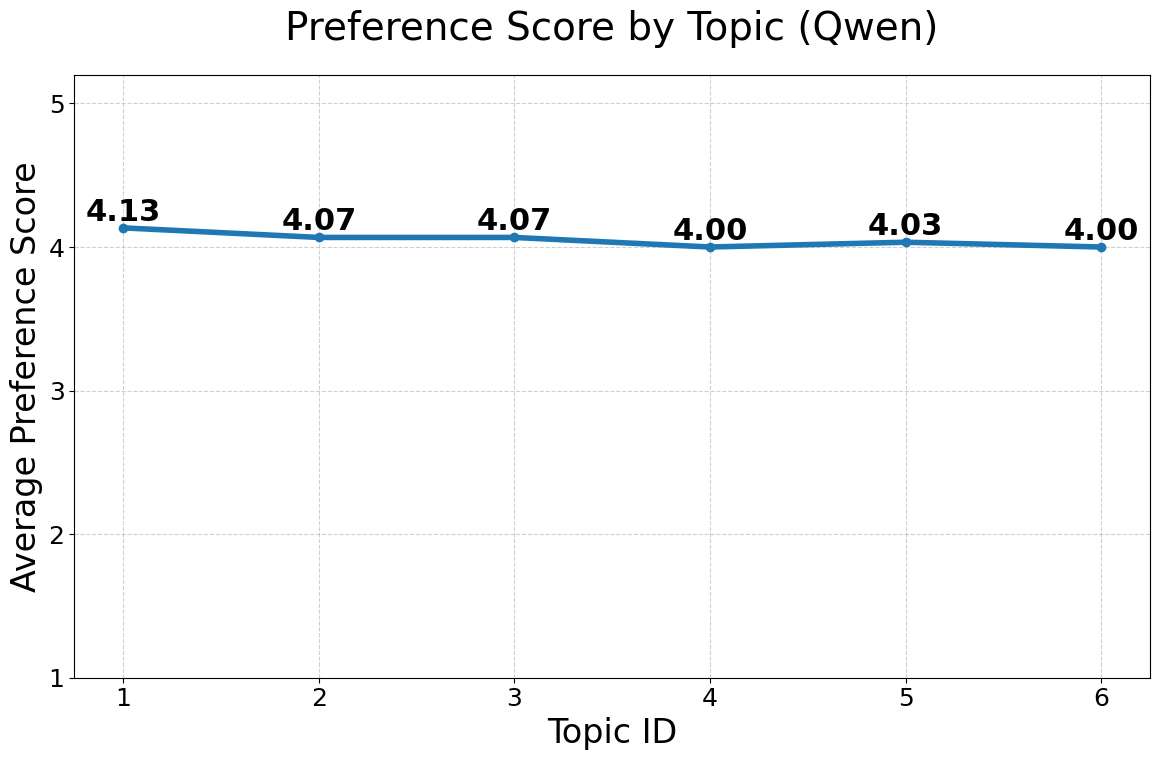

✅ Saved figure to agents_qwen2_freeagent_plot.png

📊 Processing agents_free_stance_llama3_with_score.csv ...


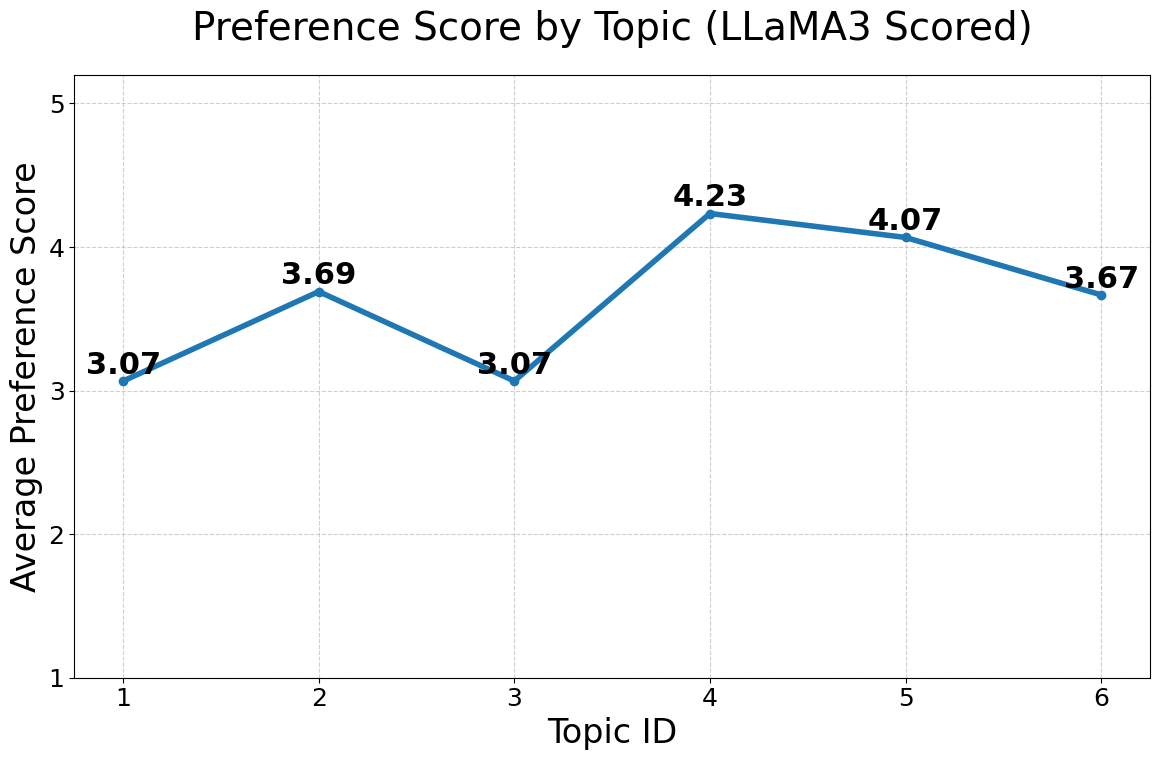

✅ Saved figure to agents_llama3_freeagent_plot.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

FILES = [
    ("agents_free_stance_qwen2_with_score.csv", "Preference Score by Topic (Qwen)", "agents_qwen2_freeagent_plot.png"),
    ("agents_free_stance_llama3_with_score.csv", "Preference Score by Topic (LLaMA3 Scored)", "agents_llama3_freeagent_plot.png")
]

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 26,
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

for file_name, title_text, out_name in FILES:
    print(f"📊 Processing {file_name} ...")

    df = pd.read_csv(file_name)
    if "Preference_Score" not in df.columns or "topic_id" not in df.columns:
        print(f"⚠️ Skipped {file_name}: missing required columns.")
        continue

    topic_mean = df.groupby("topic_id")["Preference_Score"].mean().reset_index()

    plt.figure(figsize=(12, 8))
    plt.plot(
        topic_mean["topic_id"],
        topic_mean["Preference_Score"],
        marker="o",
        linewidth=4,
        color="#1f77b4"
    )

    plt.title(title_text, fontsize=28, pad=25)
    plt.xlabel("Topic ID", fontsize=24)
    plt.ylabel("Average Preference Score", fontsize=24)
    plt.xticks(topic_mean["topic_id"])
    plt.yticks(range(1, 6))
    plt.ylim(1, 5.2)
    plt.grid(True, linestyle="--", alpha=0.6)

    for _, row in topic_mean.iterrows():
        plt.text(
            row["topic_id"], row["Preference_Score"] + 0.05,
            f"{row['Preference_Score']:.2f}",
            ha="center", fontsize=22, fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"✅ Saved figure to {out_name}\n")

In [34]:
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_drift_trajectory(csv_path, moderator_mode, model_name, selected_gaps=[0, 2, 4], save_dir=None):
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    gap_colors = {
        selected_gaps[0]: "red",
        selected_gaps[1]: "gold",
        selected_gaps[2]: "green"
    }

    df = pd.read_csv(csv_path)
    df["pref_gap"] = (df["pref_high"] - df["pref_low"]).abs()
    df["moderator_mode"] = moderator_mode

    def explode_drift(df, col_name, who):
        rows = []
        for idx, row in df.iterrows():
            try:
                seq = ast.literal_eval(row[col_name])
            except:
                continue

            for r_id, value in enumerate(seq, start=1):
                rows.append({
                    "debate_id": idx,
                    "round_id": r_id,
                    "who": who,
                    "drift": value,
                    "moderator_mode": row["moderator_mode"],
                    "pref_gap": row["pref_gap"],
                })
        return pd.DataFrame(rows)

    df_A = explode_drift(df, "drift_A_each", "A")
    df_B = explode_drift(df, "drift_B_each", "B")
    long_df = pd.concat([df_A, df_B], ignore_index=True)

    # ------------------------ Plot 1 ------------------------
    mean_traj = long_df.groupby(["moderator_mode", "round_id"])["drift"].mean().reset_index()

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=mean_traj, x="round_id", y="drift", hue="moderator_mode", marker="o")
    title1 = f"Mean Drift per Round - {moderator_mode} - {model_name}"
    plt.title(title1, fontsize=22)
    plt.xlabel("Round ID", fontsize=18)
    plt.ylabel("Mean Drift", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()

    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f"{moderator_mode}_mean_round_{model_name}.png"),
                    dpi=300, bbox_inches="tight")

    plt.show()

    # ------------------------ Plot 2 ------------------------
    mean_traj_gap = long_df.groupby(["moderator_mode", "pref_gap", "round_id"])["drift"].mean().reset_index()
    sub_gap = mean_traj_gap[mean_traj_gap["pref_gap"].isin(selected_gaps)]

    plt.figure(figsize=(8, 5))
    for gap in selected_gaps:
        data_sub = sub_gap[sub_gap["pref_gap"] == gap]
        plt.plot(
            data_sub["round_id"],
            data_sub["drift"],
            marker="o",
            color=gap_colors[gap],
            linewidth=2,
            label=f"Pref Gap {gap}"
        )

    title2 = f"Drift Trajectory by Pref Gap - {moderator_mode} - {model_name}"
    plt.title(title2, fontsize=22)
    plt.xlabel("Round ID", fontsize=18)
    plt.ylabel("Mean Drift", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.tight_layout()

    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, f"{moderator_mode}_gap_traj_{model_name}.png"),
                    dpi=300, bbox_inches="tight")

    plt.show()

    # ------------------------ Plot 3 ------------------------
    g = sns.FacetGrid(sub_gap, col="pref_gap", sharey=True, height=4, aspect=1.2)

    def facet_lineplot(data, color, **kwargs):
        gap = data["pref_gap"].iloc[0]
        plt.plot(
            data["round_id"],
            data["drift"],
            marker="o",
            color=gap_colors[gap],
            linewidth=2
        )

    g.map_dataframe(facet_lineplot)
    title3 = f"Drift Trajectory Facet by Pref Gap - {moderator_mode} - {model_name}"
    g.fig.suptitle(title3, fontsize=22, y=1.05)
    g.set_axis_labels("Round ID", "Mean Drift")

    plt.tight_layout()

    if save_dir is not None:
        g.savefig(os.path.join(save_dir, f"{moderator_mode}_facet_{model_name}.png"),
                  dpi=300, bbox_inches="tight")

    plt.show()

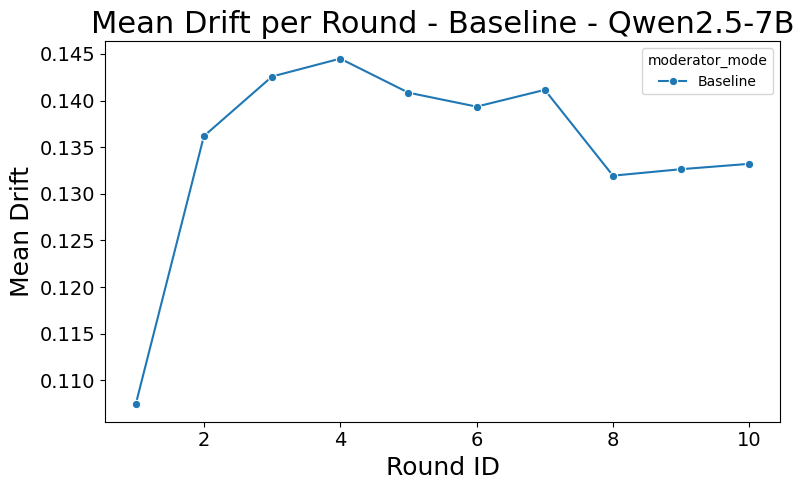

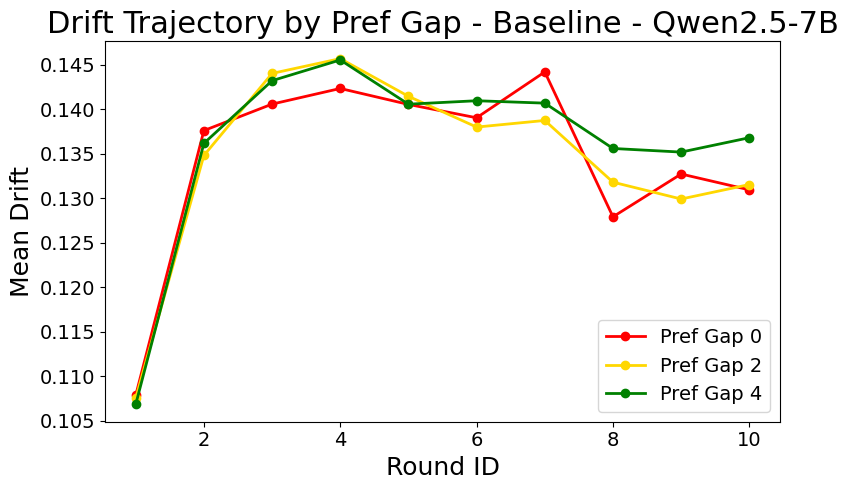

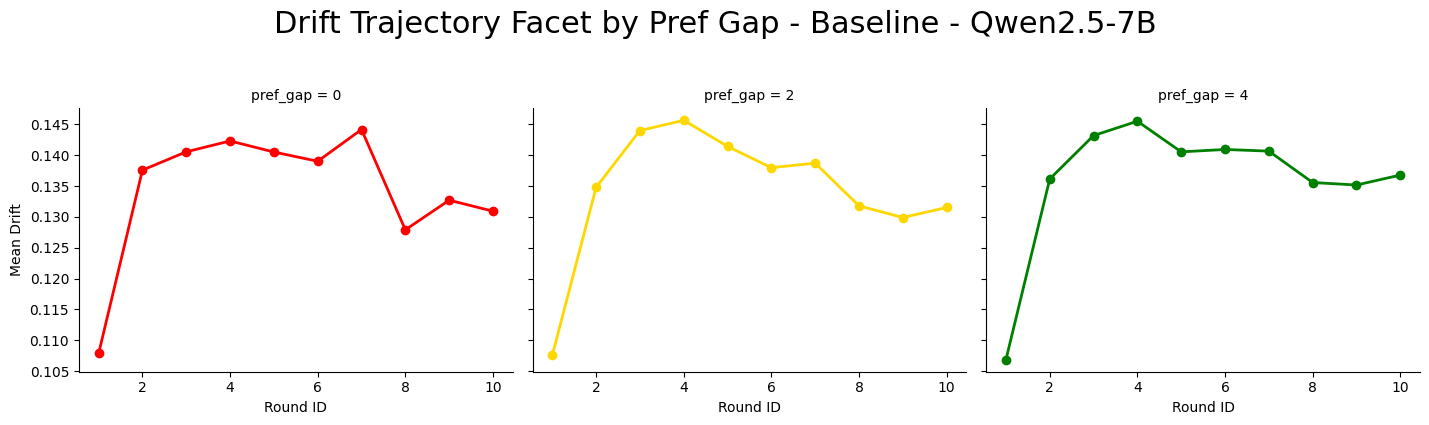

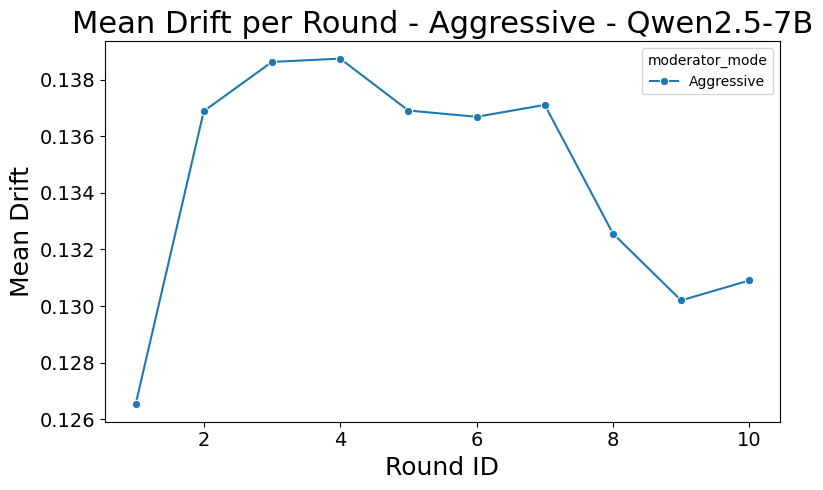

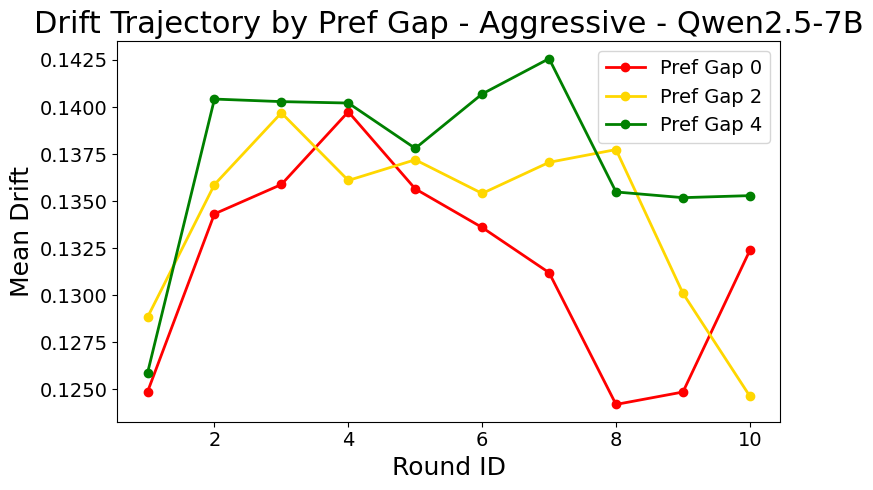

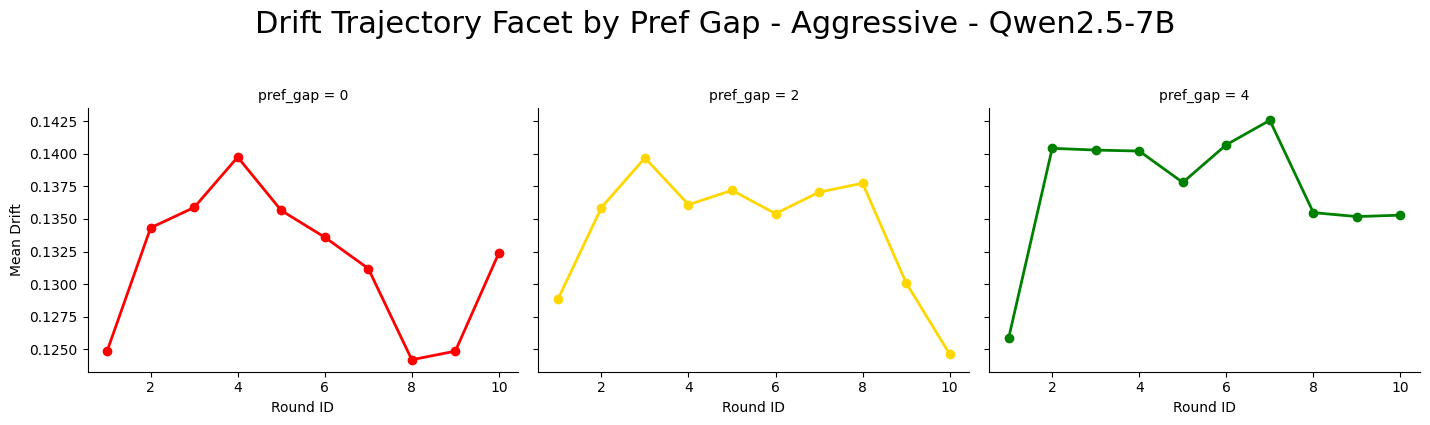

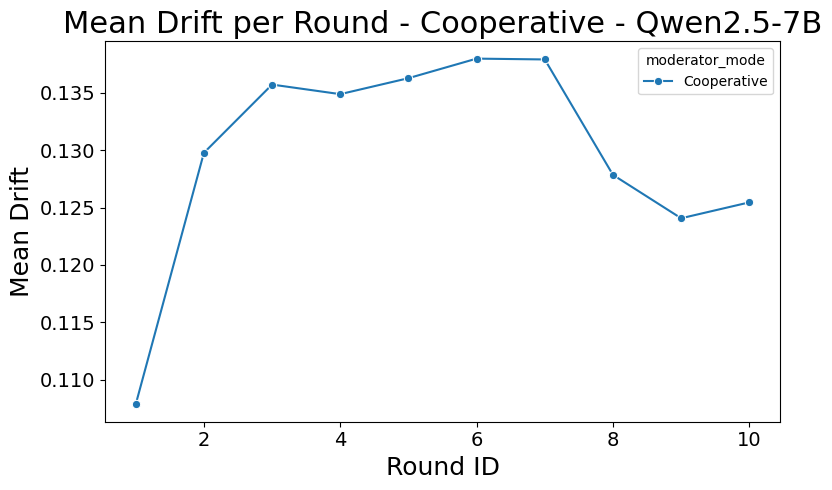

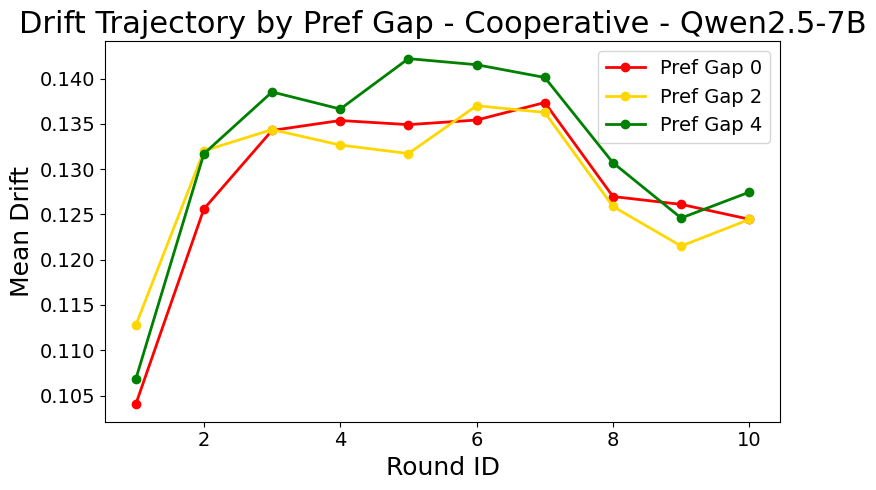

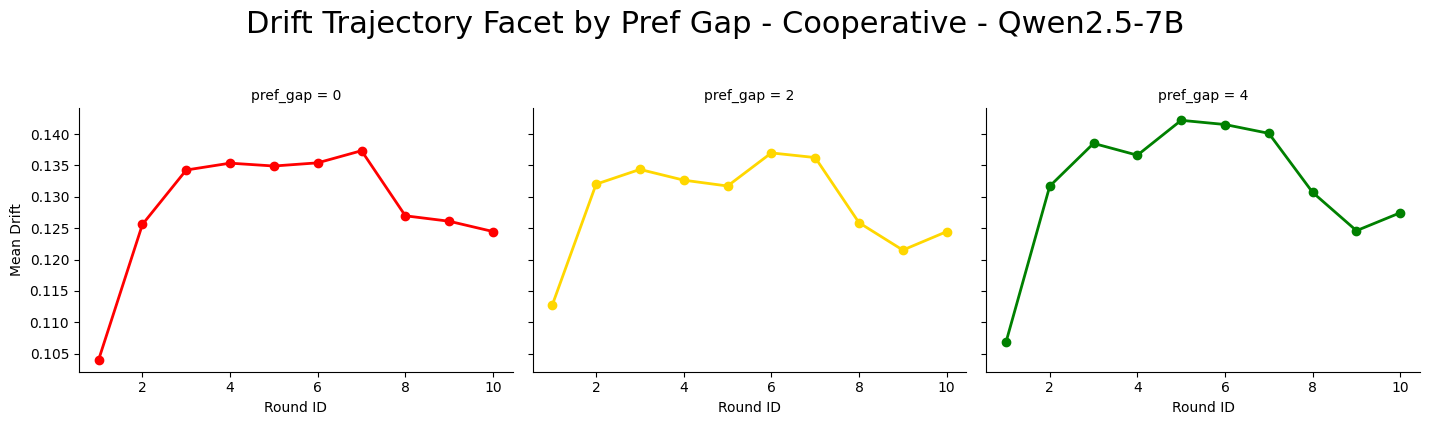

In [27]:
analyze_drift_trajectory(
    "batch_debate_results_QWEN.baseline.csv",
    moderator_mode="Baseline",
    model_name="Qwen2.5-7B",
    save_dir="trajectory_qwen_plots_baseline"
)

analyze_drift_trajectory(
    "batch_debate_results_QWEN_aggressive.csv",
    moderator_mode="Aggressive",
    model_name="Qwen2.5-7B",
    save_dir="trajectory_qwen_plots_aggressive"
)

analyze_drift_trajectory(
    "batch_debate_results_QWEN_cooperative.csv",
    moderator_mode="Cooperative",
    model_name="Qwen2.5-7B",
    save_dir="trajectory_qwen_plots_cooperative"
)

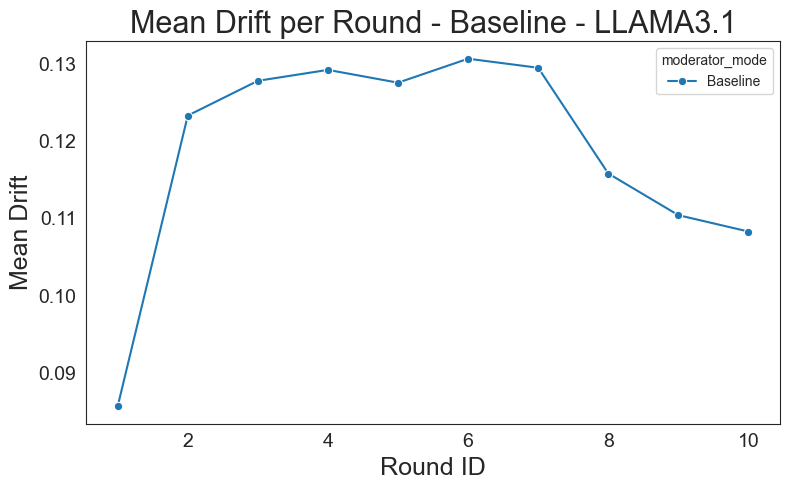

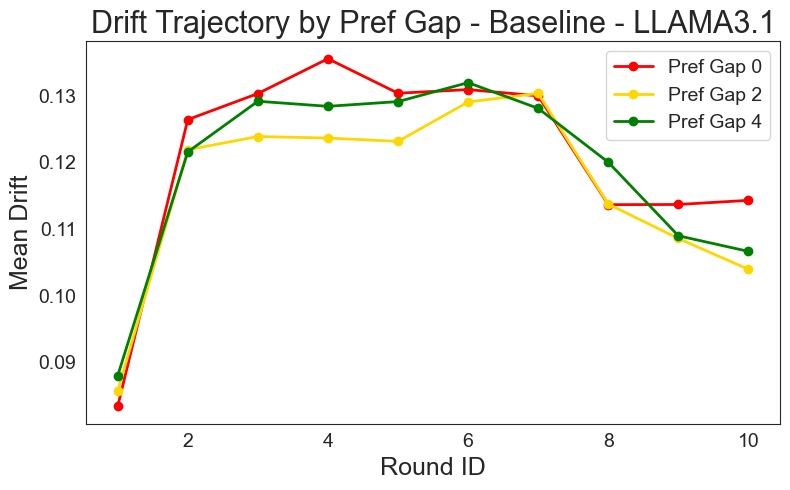

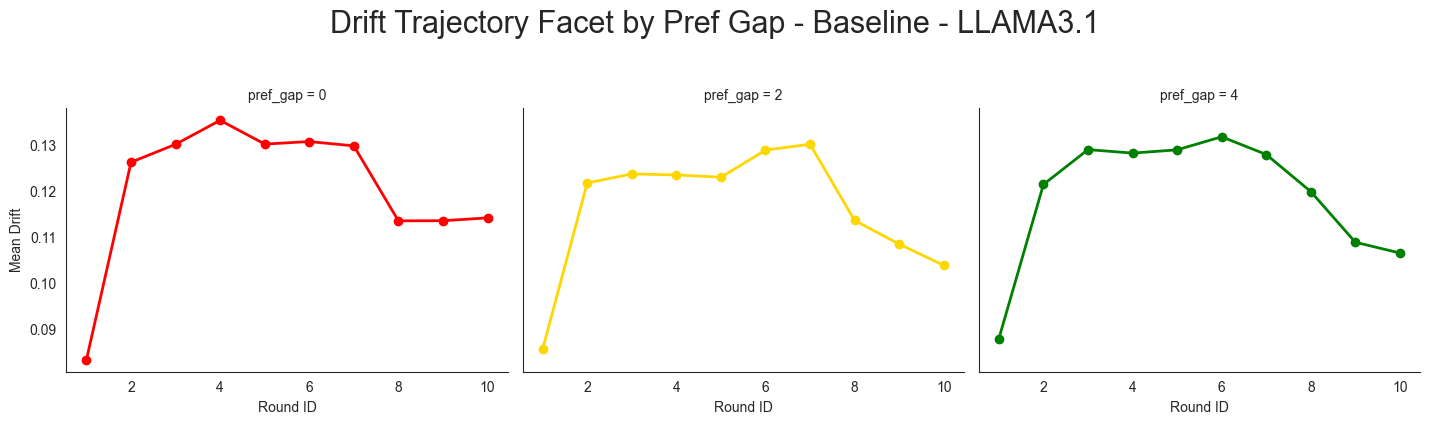

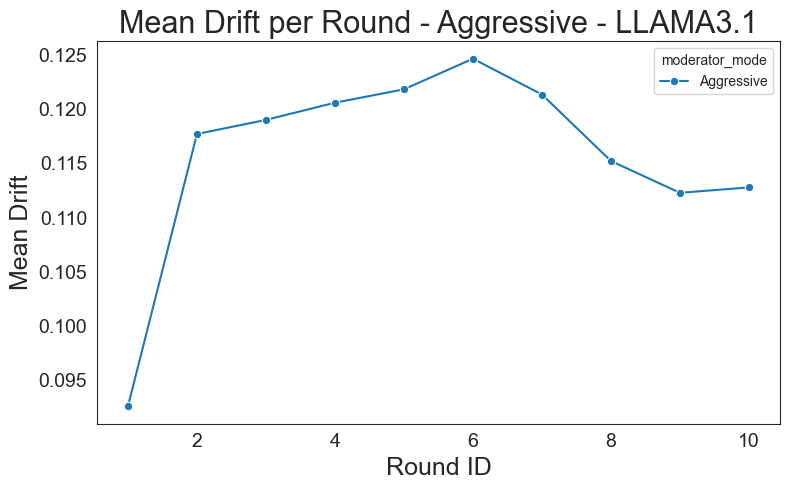

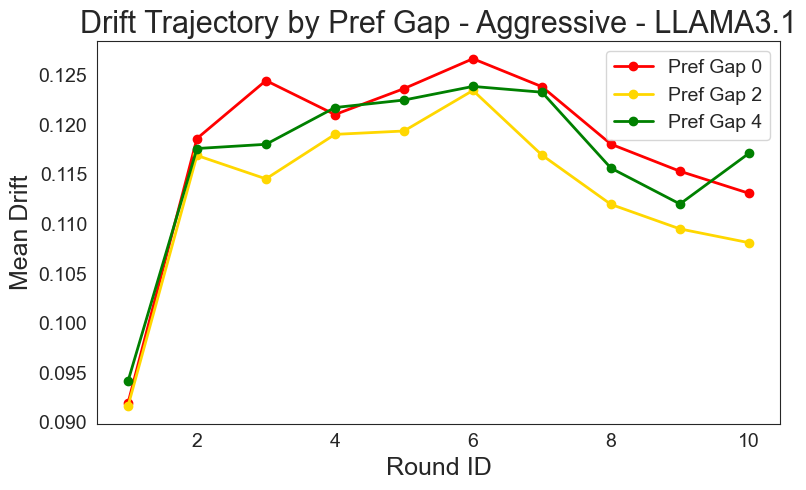

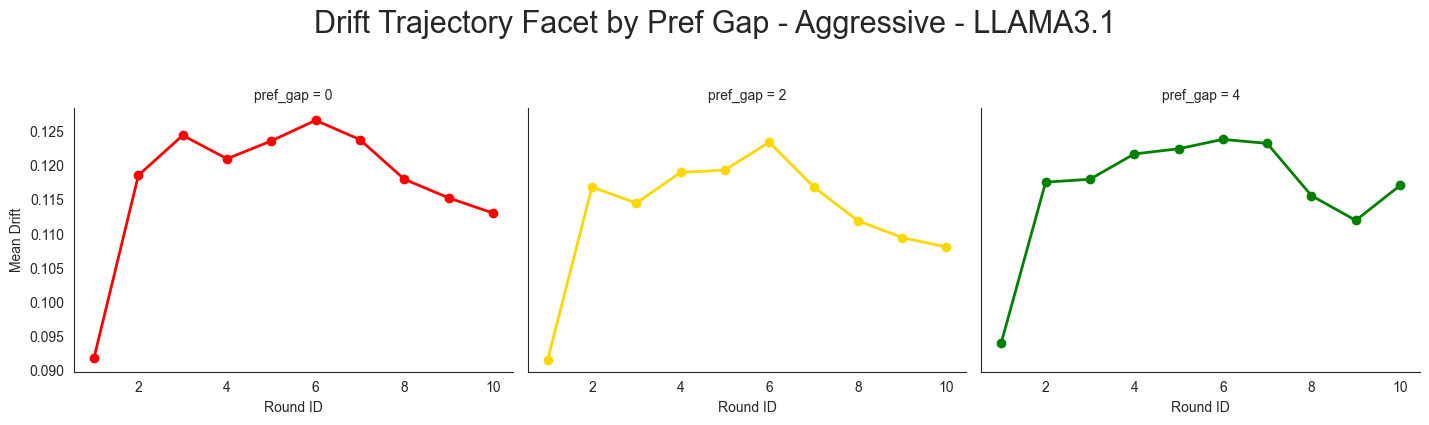

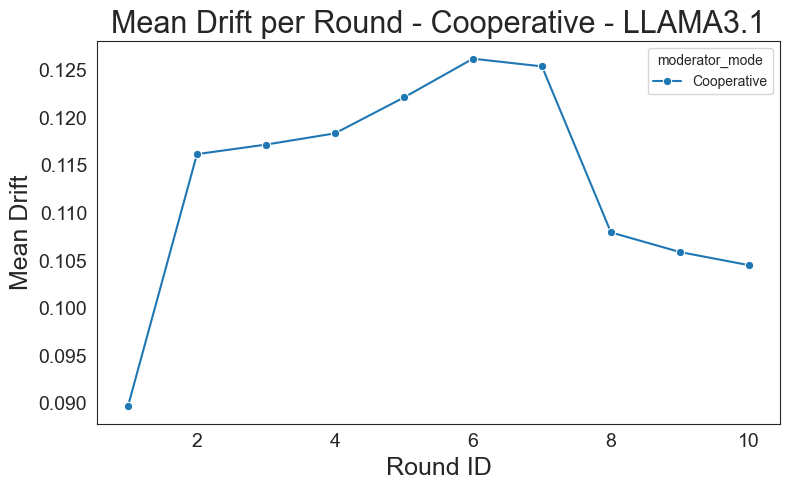

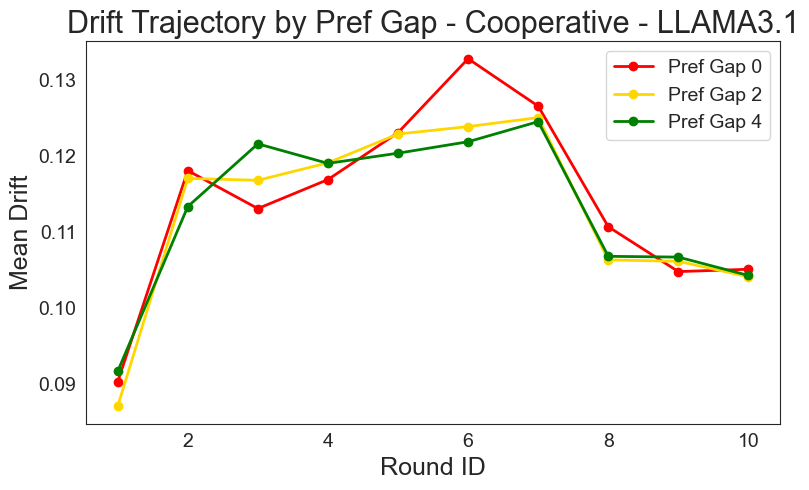

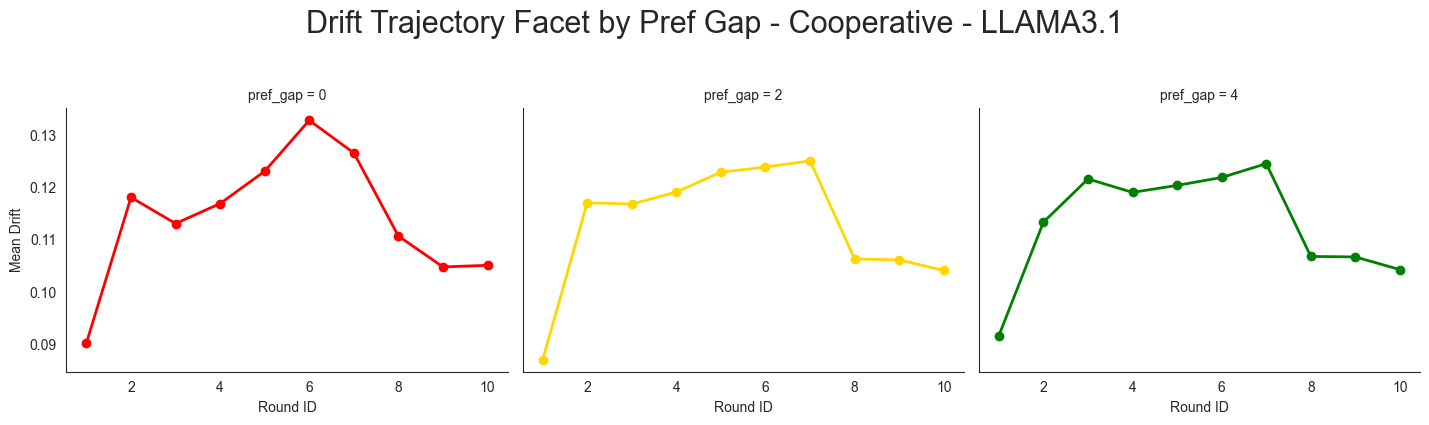

In [37]:
analyze_drift_trajectory(
    "batch_debate_results_LLAMA_baseline.csv",
    moderator_mode="Baseline",
    model_name="LLAMA3.1",
    save_dir="trajectory_llama3_plots_baseline"
)

analyze_drift_trajectory(
    "batch_debate_results_LLAMA_aggressive.csv",
    moderator_mode="Aggressive",
    model_name="LLAMA3.1",
    save_dir="trajectory_llama3_plots_aggressive"
)

analyze_drift_trajectory(
    "batch_debate_results_LLAMA_cooperative.csv",
    moderator_mode="Cooperative",
    model_name="LLAMA3.1",
    save_dir="trajectory_llama3_plots_cooperative"
)

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_drift_by_topic_category(
    debate_csv_path,
    topic_csv_path,
    mode_name=None,
    model_name=None,
    save_path=None
):
    # Load debate results
    df = pd.read_csv(debate_csv_path)
    
    # Load topic info
    topics = pd.read_csv(topic_csv_path)
    
    # Merge debate results with topic category
    df = df.merge(topics[["topic_id", "topic_category"]], on="topic_id", how="left")

    # Combine drift A and B into long format
    df_long = pd.concat([
        df[["topic_category", "final_drift_A"]].rename(columns={"final_drift_A": "drift"}),
        df[["topic_category", "final_drift_B"]].rename(columns={"final_drift_B": "drift"})
    ], ignore_index=True)

    # --- Plot KDE curves ---
    plt.figure(figsize=(8, 5))
    sns.kdeplot(
        data=df_long,
        x="drift",
        hue="topic_category",
        linewidth=3
    )

    # Build title
    title_parts = ["Final Drift KDE by Topic Category"]
    if mode_name:
        title_parts.append(mode_name)
    if model_name:
        title_parts.append(model_name)

    title = " - ".join(title_parts)

    plt.title(title, fontsize=22)
    plt.xlabel("Final Drift", fontsize=18)
    plt.ylabel("Density", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

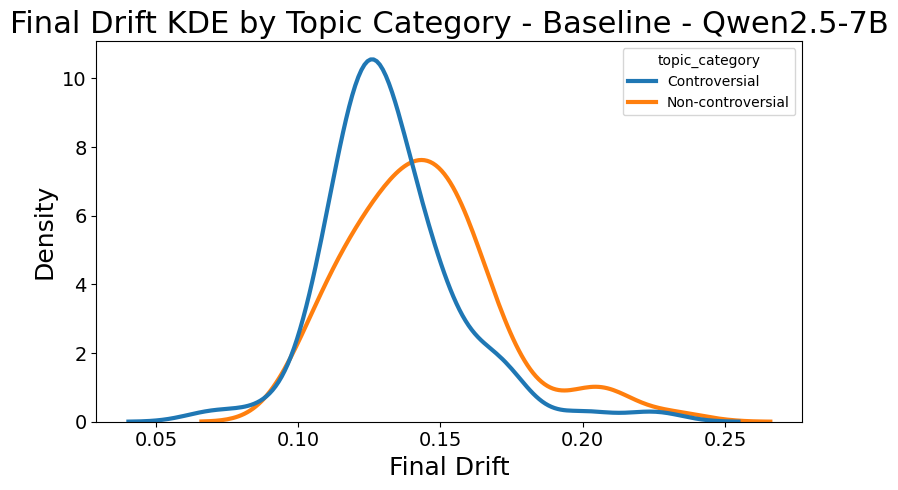

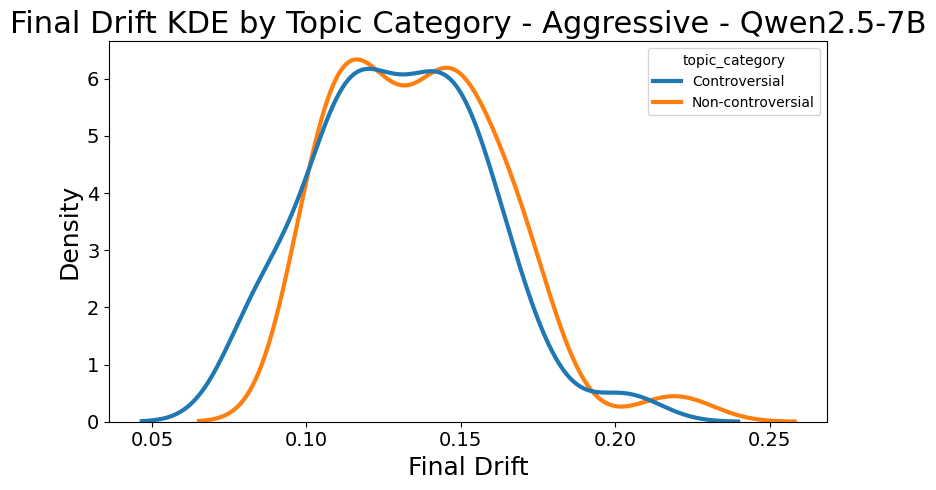

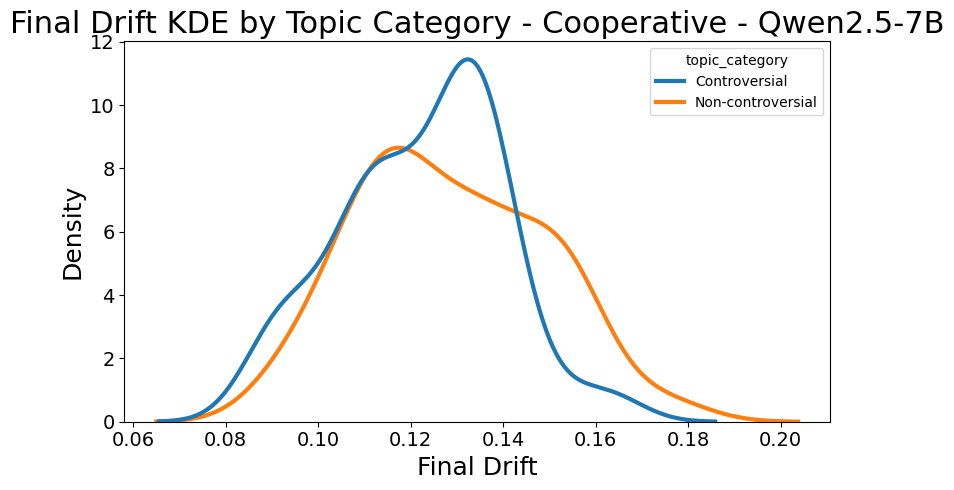

In [32]:
plot_drift_by_topic_category(
    "batch_debate_results_QWEN.baseline.csv",
    "topics.csv",
    mode_name="Baseline",
    model_name="Qwen2.5-7B",
    save_path="drift_by_category_baseline.png"
)

plot_drift_by_topic_category(
    "batch_debate_results_QWEN_aggressive.csv",
    "topics.csv",
    mode_name="Aggressive",
    model_name="Qwen2.5-7B",
    save_path="drift_by_category_aggressive.png"
)

plot_drift_by_topic_category(
    "batch_debate_results_QWEN_cooperative.csv",
    "topics.csv",
    mode_name="Cooperative",
    model_name="Qwen2.5-7B",
    save_path="drift_by_category_coop.png"
)

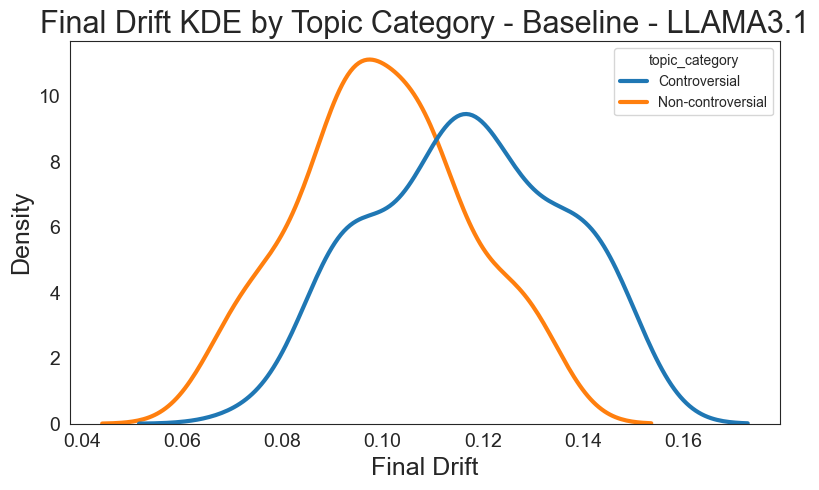

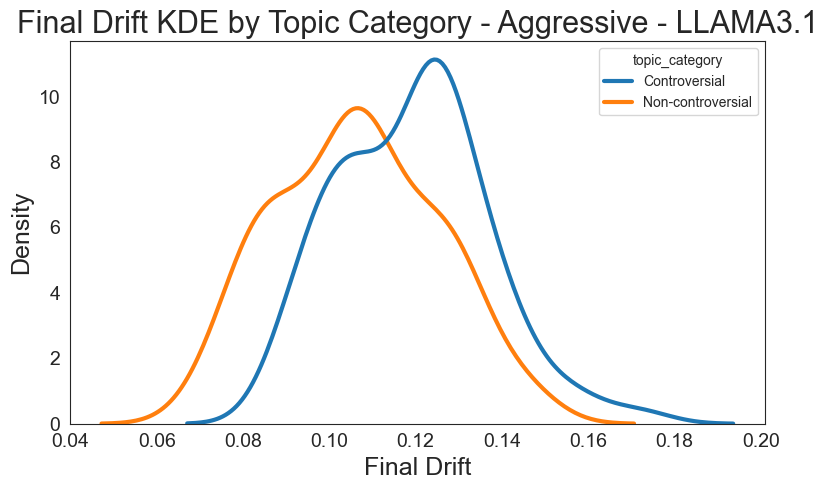

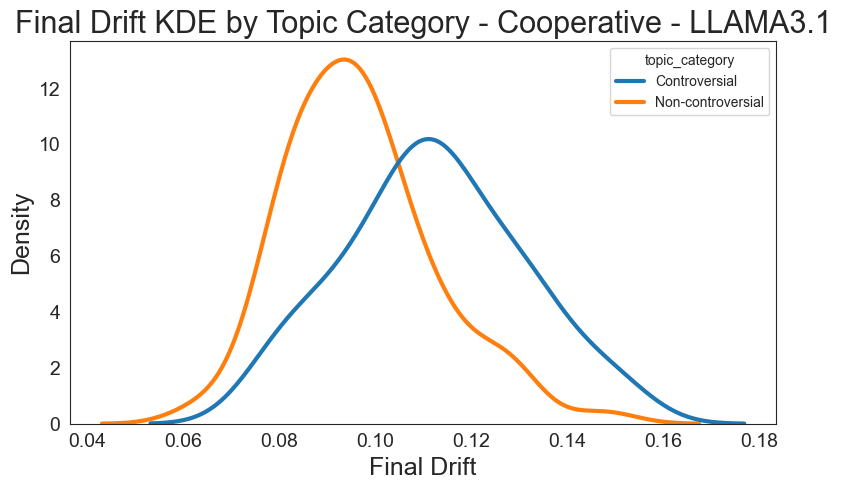

In [39]:
plot_drift_by_topic_category(
    "batch_debate_results_LLAMA_baseline.csv",
    "topics.csv",
    mode_name="Baseline",
    model_name="LLAMA3.1",
    save_path="LLAMA3_drift_by_category_baseline.png"
)

plot_drift_by_topic_category(
    "batch_debate_results_LLAMA_aggressive.csv",
    "topics.csv",
    mode_name="Aggressive",
    model_name="LLAMA3.1",
    save_path="LLAMA3_drift_by_category_aggressive.png"
)

plot_drift_by_topic_category(
    "batch_debate_results_LLAMA_cooperative.csv",
    "topics.csv",
    mode_name="Cooperative",
    model_name="LLAMA3.1",
    save_path="LLAMA3_drift_by_category_coop.png"
)

In [33]:
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns


def analyze_drift_trajectory_by_topic(
    csv_path,
    topics_csv,            
    moderator_mode,
    model_name,
    selected_gaps=[0, 2, 4],
    save_dir=None
):
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    gap_colors = {
        selected_gaps[0]: "red",
        selected_gaps[1]: "gold",
        selected_gaps[2]: "green"
    }

    # ---------------- Load debate results ----------------
    df = pd.read_csv(csv_path)
    df["pref_gap"] = (df["pref_high"] - df["pref_low"]).abs()
    df["moderator_mode"] = moderator_mode

    # ---------------- Load topic category ----------------
    topics = pd.read_csv(topics_csv)   
    df = df.merge(topics, on="topic_id", how="left")

    # ---------------- Explode drift sequences ----------------
    def explode_drift(df, col_name, who):
        rows = []
        for idx, row in df.iterrows():
            try:
                seq = ast.literal_eval(row[col_name])
            except:
                continue

            for r_id, value in enumerate(seq, start=1):
                rows.append({
                    "debate_id": idx,
                    "round_id": r_id,
                    "who": who,
                    "drift": value,
                    "moderator_mode": row["moderator_mode"],
                    "pref_gap": row["pref_gap"],
                    "topic_category": row["topic_category"],
                })
        return pd.DataFrame(rows)

    df_A = explode_drift(df, "drift_A_each", "A")
    df_B = explode_drift(df, "drift_B_each", "B")
    long_df = pd.concat([df_A, df_B], ignore_index=True)

    # =========================================================
    # LOOP: For each topic_category (Controversial / Non...)
    # =========================================================
    for cat in long_df["topic_category"].unique():

        cat_df = long_df[long_df["topic_category"] == cat]

        print(f"\n=== Plotting category: {cat} ===")

        # ---------------- Plot 1: mean drift by round ----------------
        mean_traj = (
            cat_df.groupby(["round_id"])["drift"]
            .mean()
            .reset_index()
        )

        plt.figure(figsize=(8, 5))
        plt.plot(mean_traj["round_id"], mean_traj["drift"],
                 marker="o", linewidth=2, color="steelblue")

        title1 = f"Mean Drift per Round - {moderator_mode} - {model_name} - {cat}"
        plt.title(title1, fontsize=22)
        plt.xlabel("Round ID", fontsize=18)
        plt.ylabel("Mean Drift", fontsize=18)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()

        if save_dir:
            plt.savefig(
                os.path.join(save_dir, f"{moderator_mode}_{cat}_mean_round_{model_name}.png"),
                dpi=300, bbox_inches="tight"
            )
        plt.show()

        # ---------------- Plot 2: trajectory by pref_gap ----------------
        mean_traj_gap = (
            cat_df.groupby(["pref_gap", "round_id"])["drift"]
            .mean()
            .reset_index()
        )
        sub_gap = mean_traj_gap[mean_traj_gap["pref_gap"].isin(selected_gaps)]

        plt.figure(figsize=(8, 5))
        for gap in selected_gaps:
            gap_data = sub_gap[sub_gap["pref_gap"] == gap]
            plt.plot(
                gap_data["round_id"],
                gap_data["drift"],
                marker="o",
                linewidth=2,
                color=gap_colors[gap],
                label=f"Pref Gap {gap}"
            )

        title2 = f"Drift Trajectory by Pref Gap - {moderator_mode} - {model_name} - {cat}"
        plt.title(title2, fontsize=22)
        plt.xlabel("Round ID", fontsize=18)
        plt.ylabel("Mean Drift", fontsize=18)
        plt.legend(fontsize=14)
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.tight_layout()

        if save_dir:
            plt.savefig(
                os.path.join(save_dir, f"{moderator_mode}_{cat}_gap_traj_{model_name}.png"),
                dpi=300, bbox_inches="tight"
            )
        plt.show()

        # ---------------- Plot 3: facet by pref_gap ----------------
        g = sns.FacetGrid(sub_gap, col="pref_gap", sharey=True, height=4, aspect=1.2)

        def facet_plot(data, color, **kwargs):
            gap = data["pref_gap"].iloc[0]
            plt.plot(
                data["round_id"],
                data["drift"],
                marker="o",
                linewidth=2,
                color=gap_colors[gap]
            )

        g.map_dataframe(facet_plot)
        title3 = f"Drift Trajectory Facet by Gap - {moderator_mode} - {model_name} - {cat}"
        g.fig.suptitle(title3, fontsize=22, y=1.05)
        g.set_axis_labels("Round ID", "Mean Drift")
        plt.tight_layout()

        if save_dir:
            g.savefig(
                os.path.join(save_dir, f"{moderator_mode}_{cat}_facet_{model_name}.png"),
                dpi=300, bbox_inches="tight"
            )

        plt.show()


=== Plotting category: Controversial ===


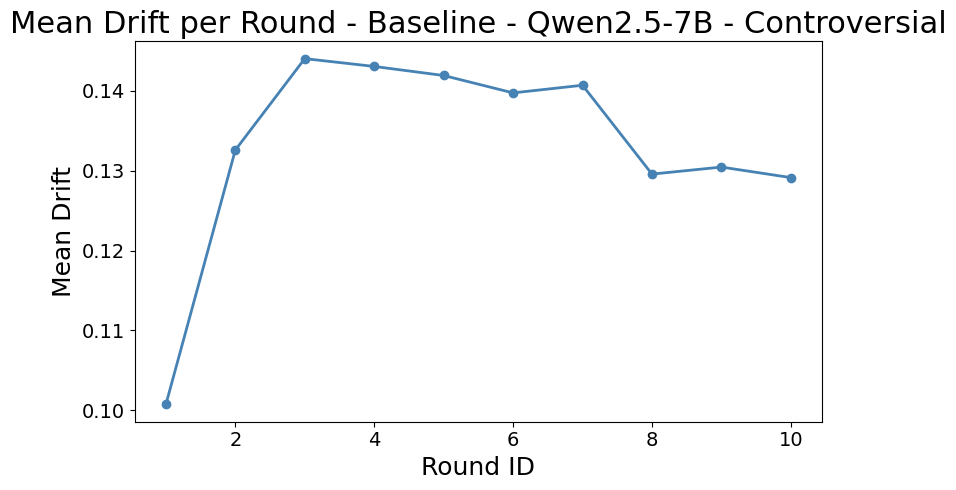

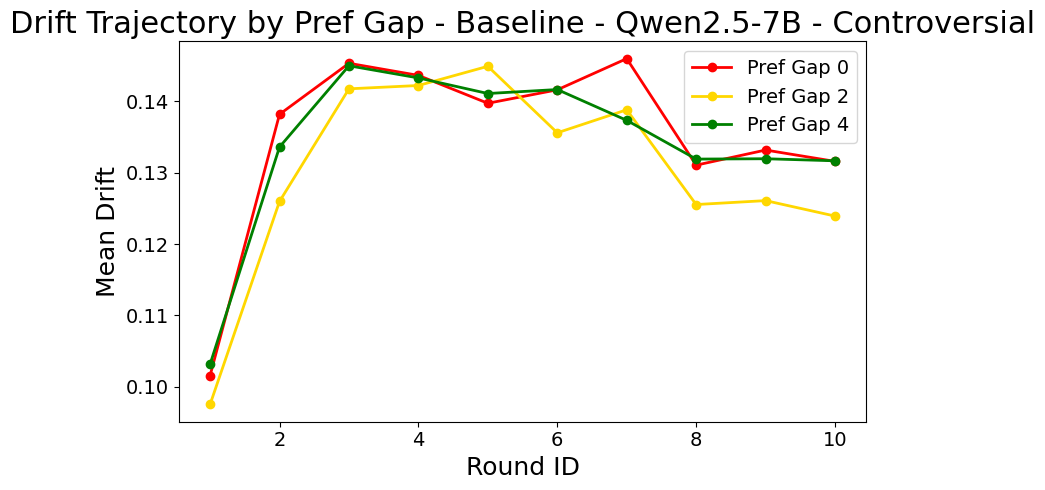

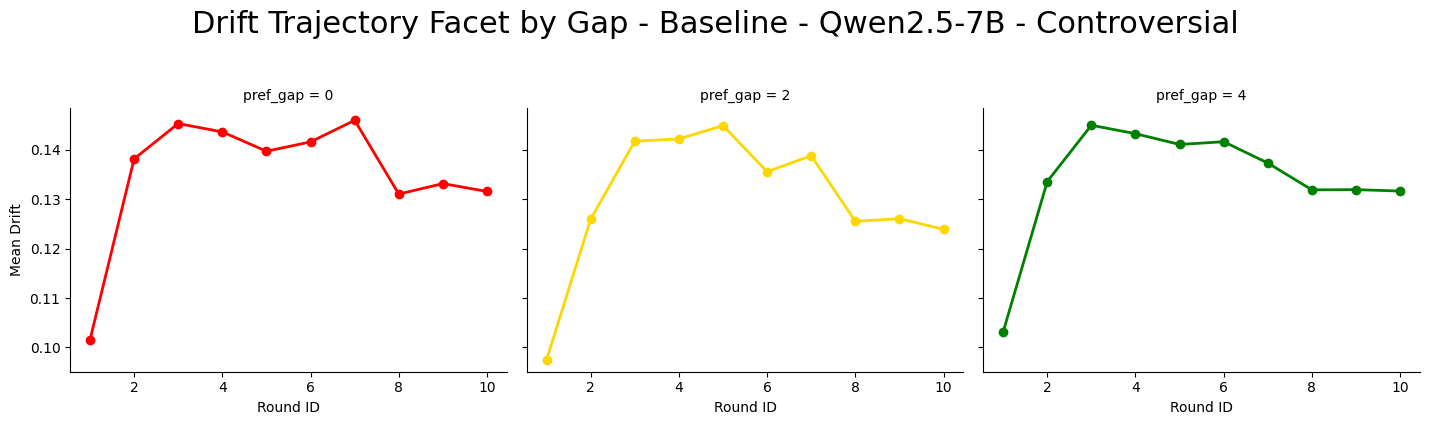


=== Plotting category: Non-controversial ===


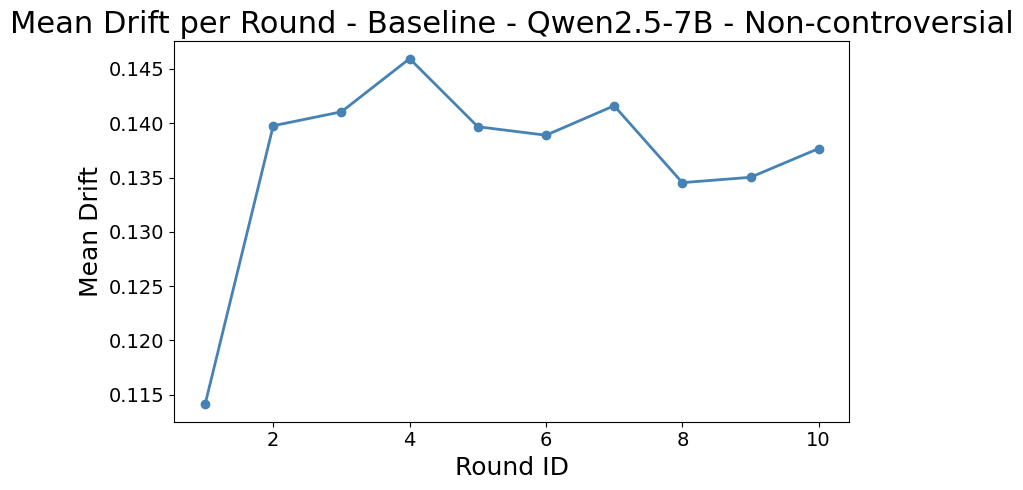

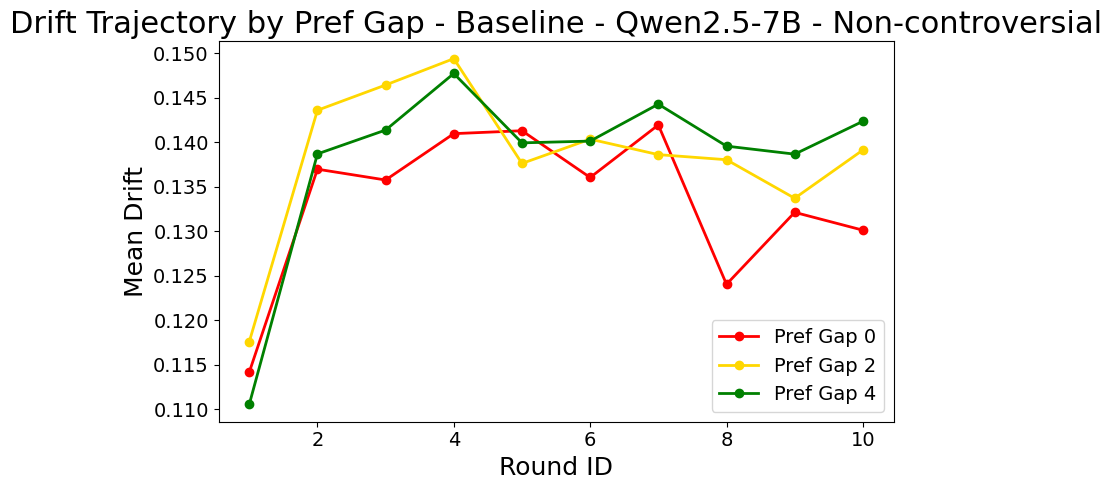

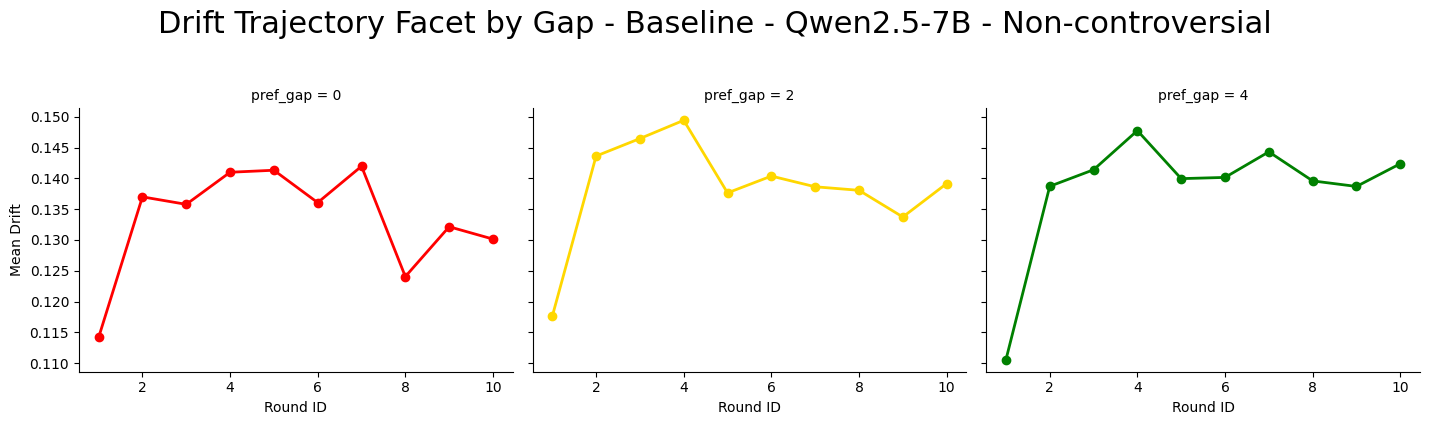


=== Plotting category: Controversial ===


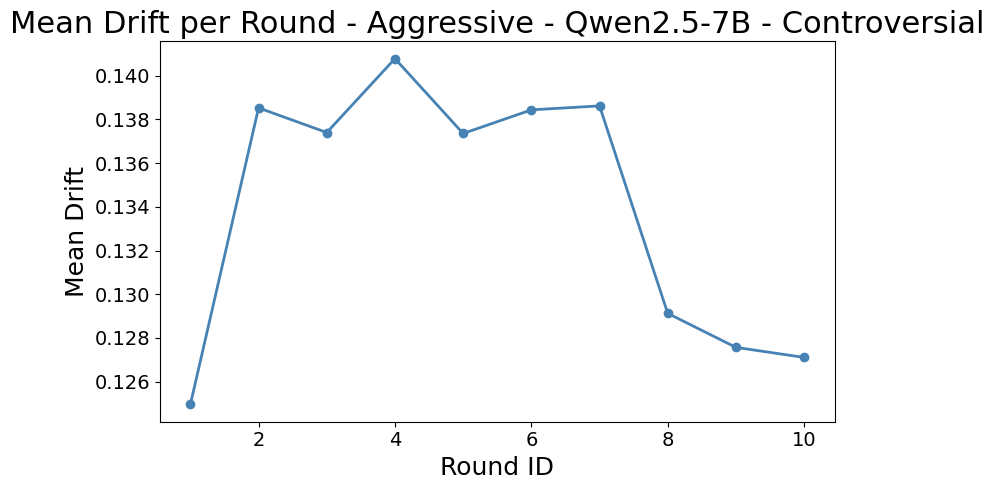

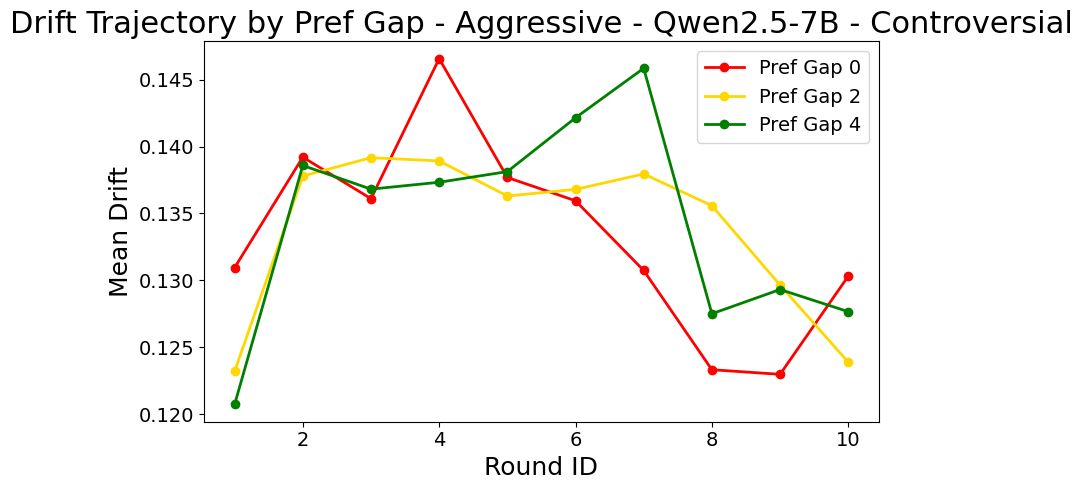

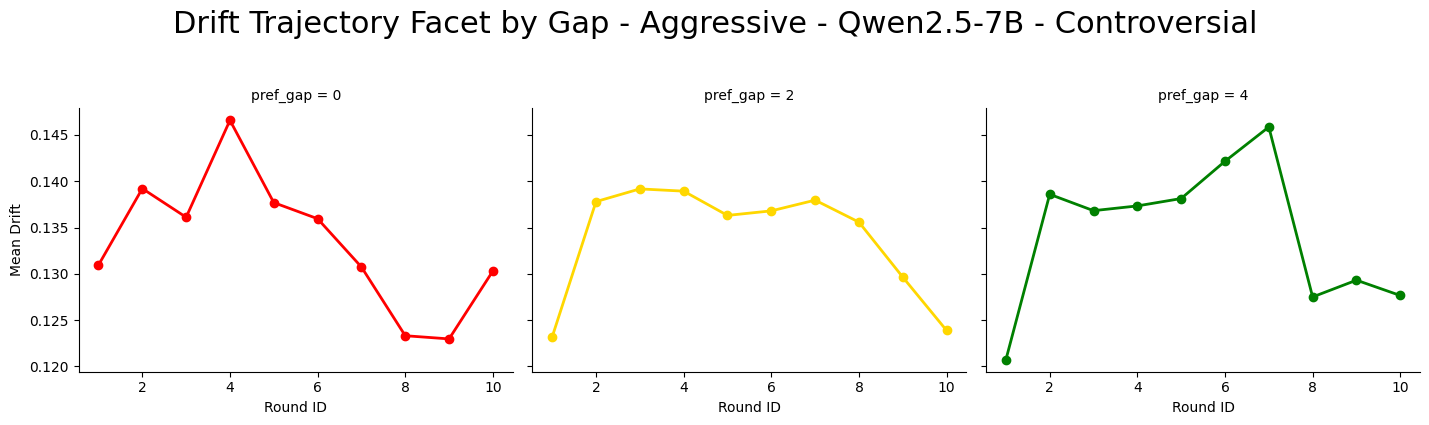


=== Plotting category: Non-controversial ===


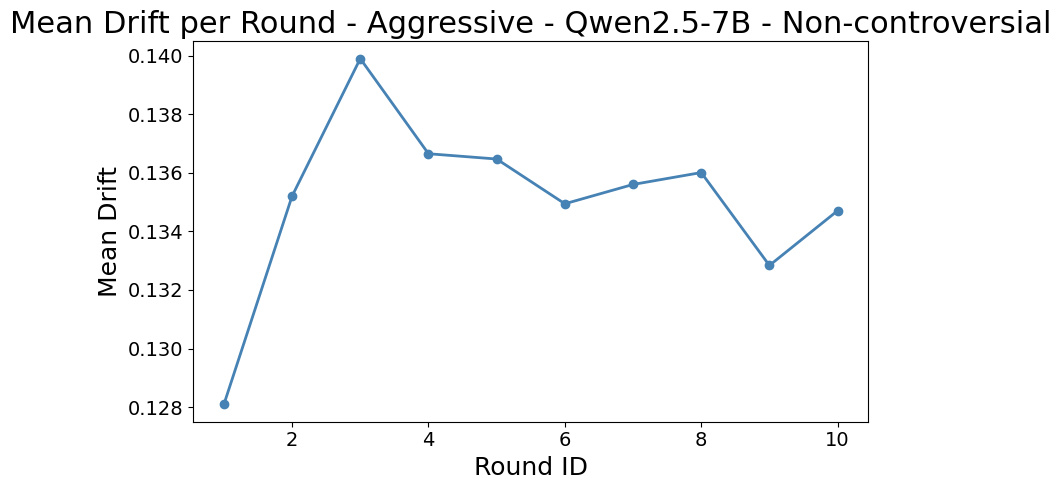

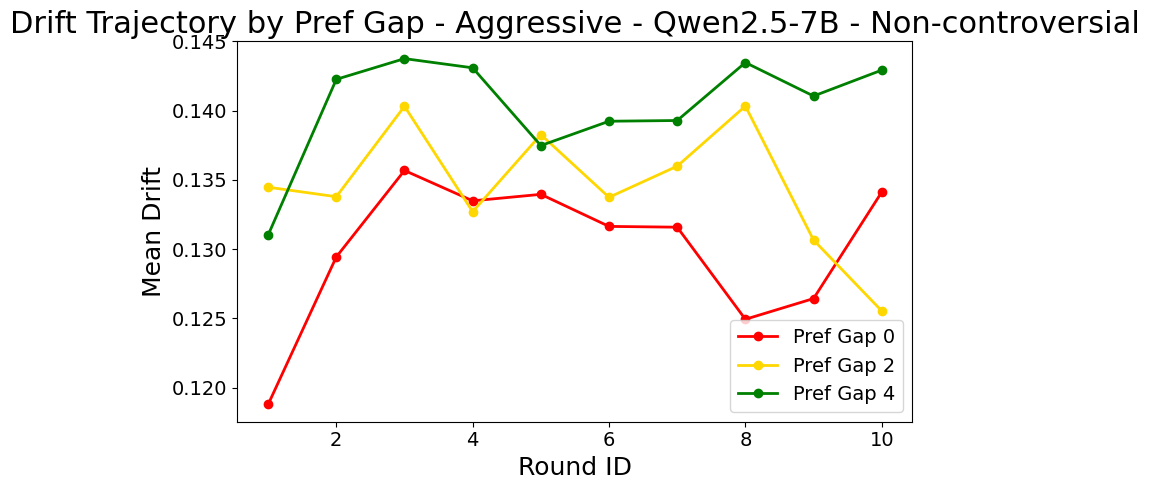

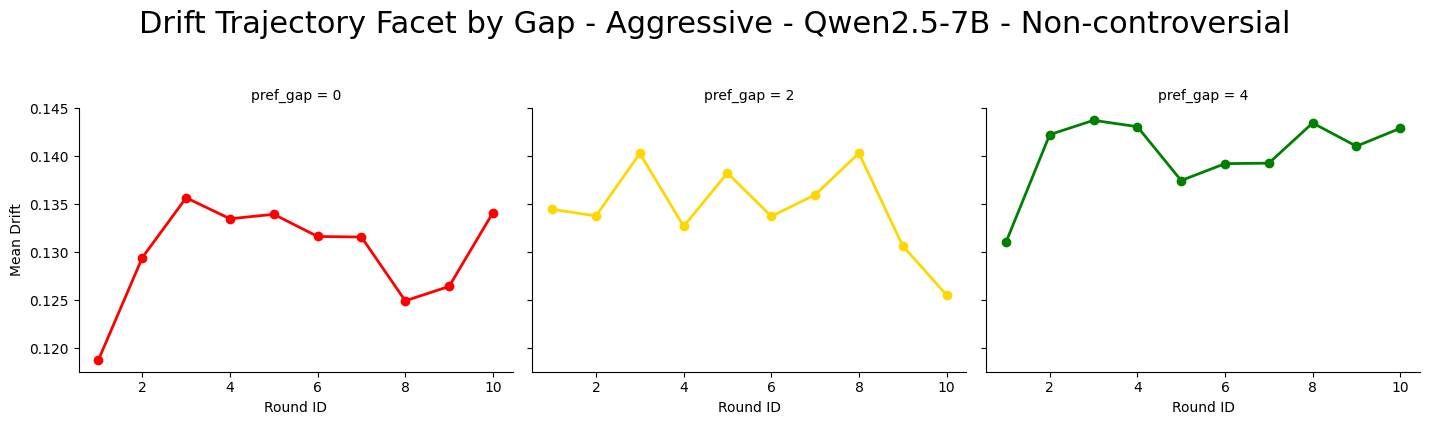


=== Plotting category: Controversial ===


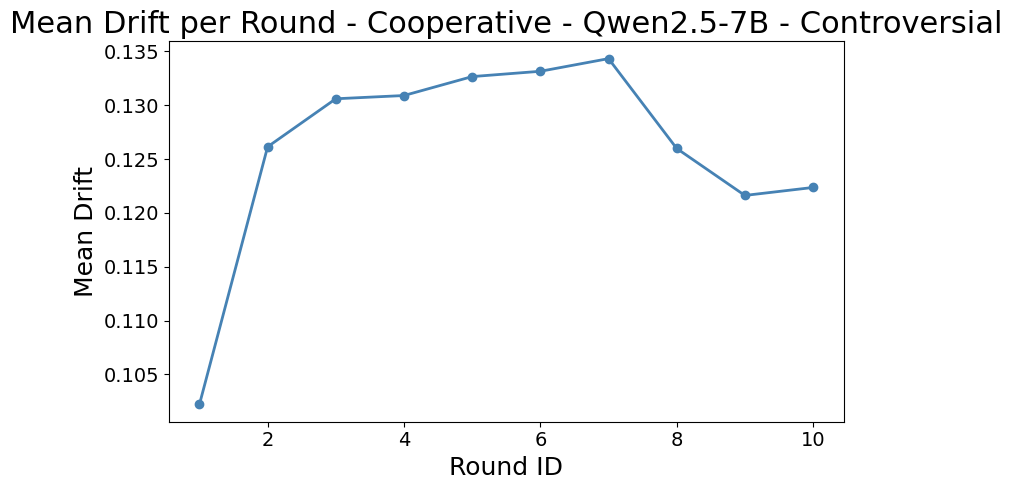

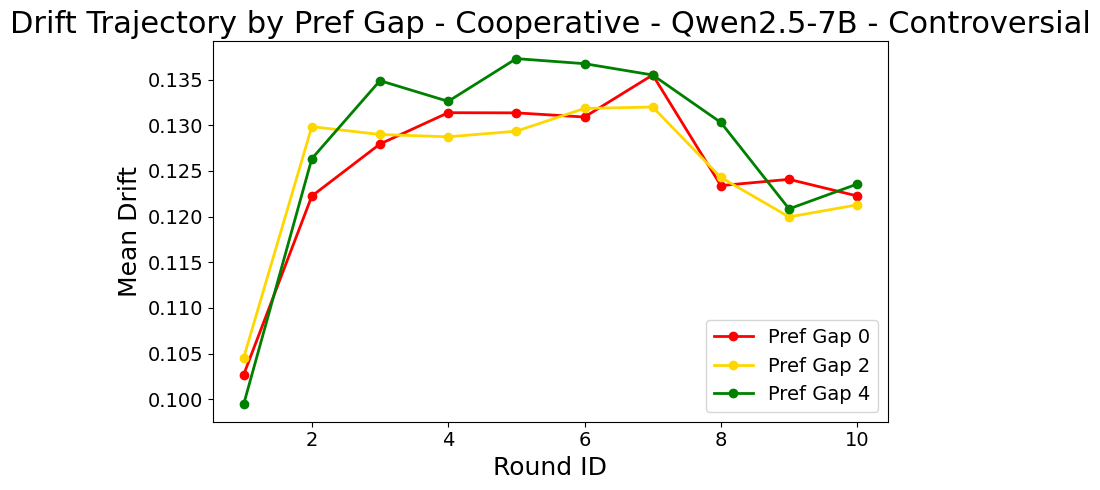

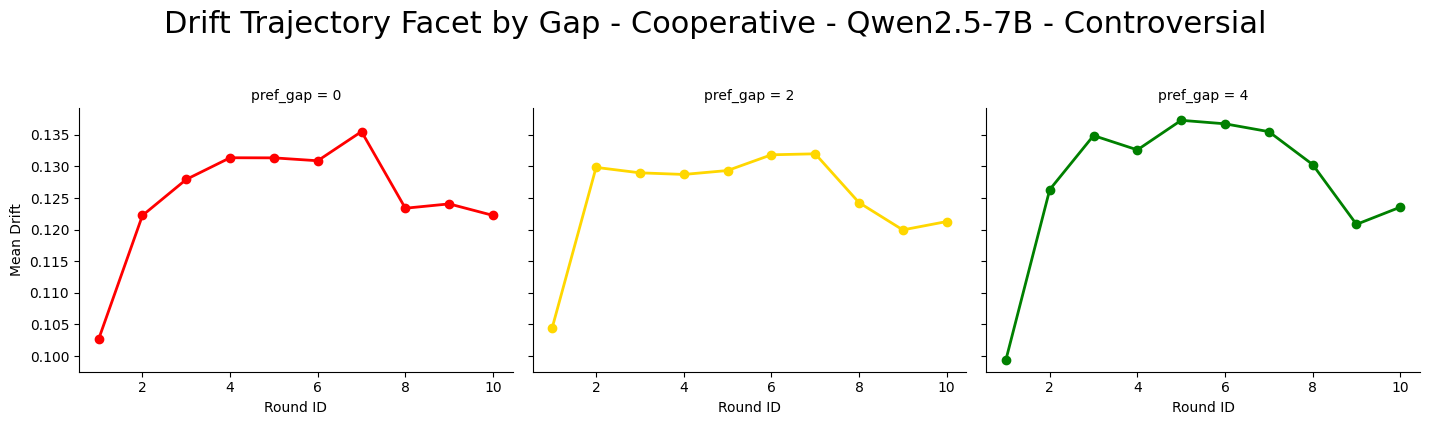


=== Plotting category: Non-controversial ===


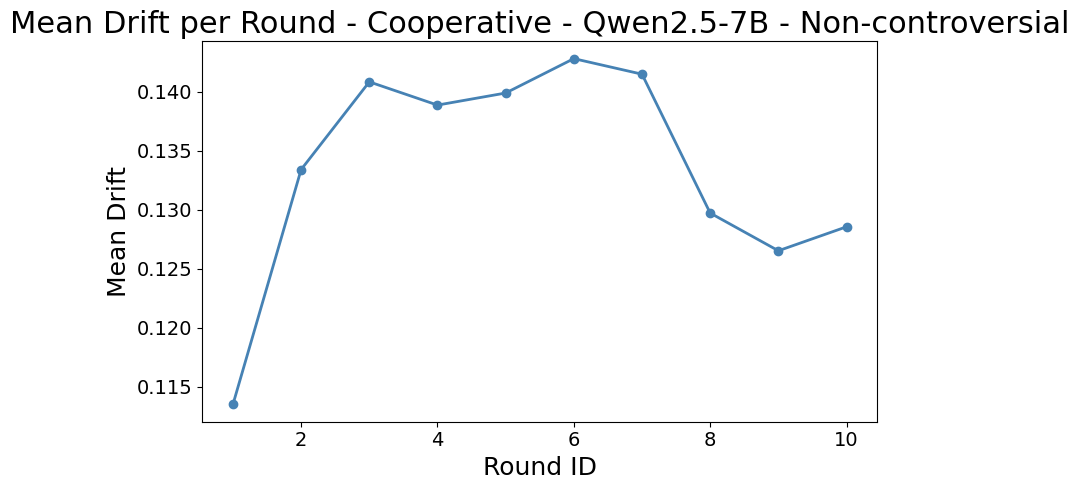

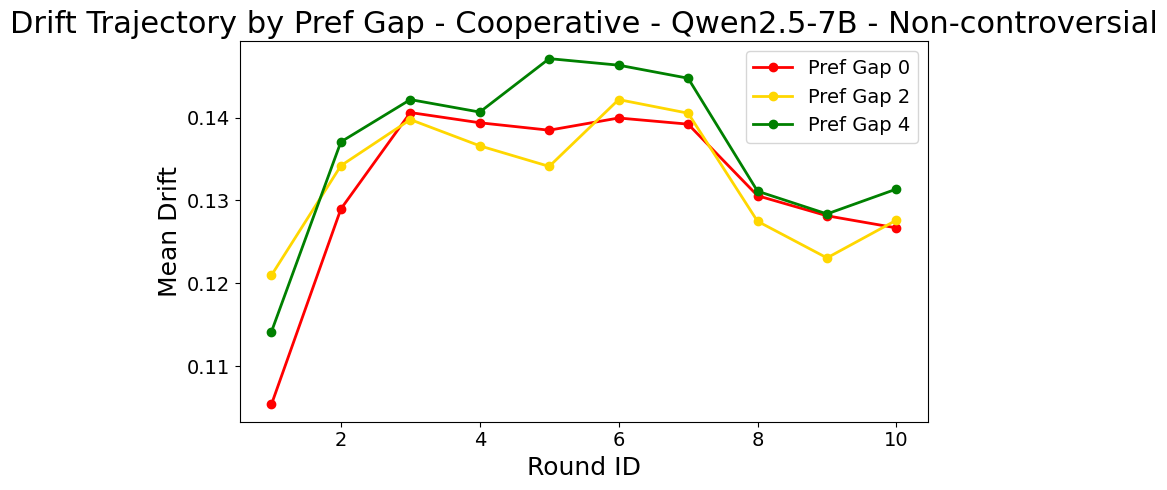

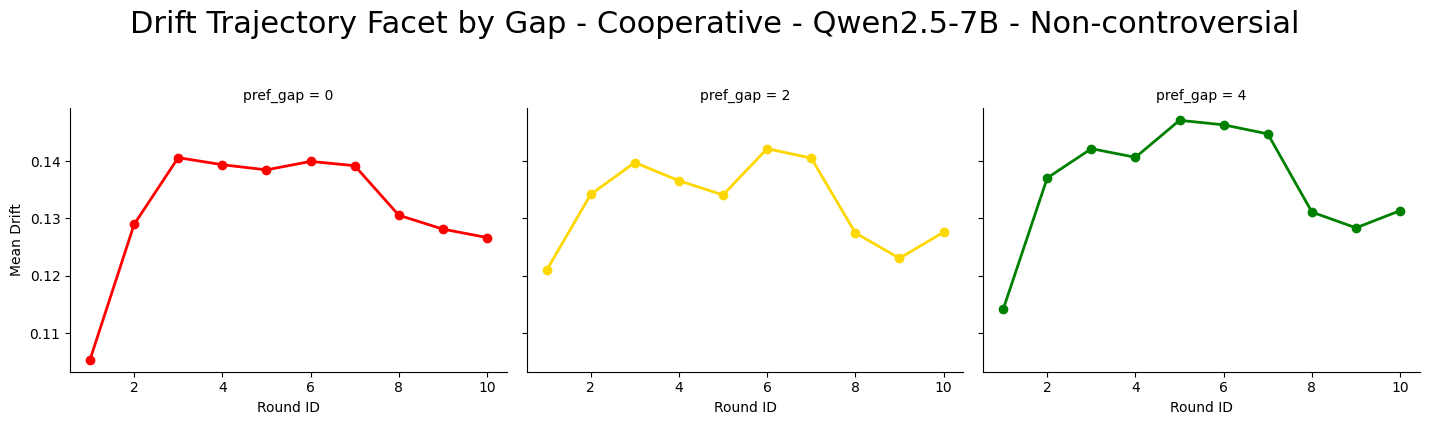

In [34]:
analyze_drift_trajectory_by_topic(
    "batch_debate_results_QWEN.baseline.csv",
    "topics.csv",
    moderator_mode="Baseline",
    model_name="Qwen2.5-7B",
    save_dir="plots/baseline"
)

analyze_drift_trajectory_by_topic(
    "batch_debate_results_QWEN_aggressive.csv",
    "topics.csv",
    moderator_mode="Aggressive",
    model_name="Qwen2.5-7B",
    save_dir="plots/aggressive"
)

analyze_drift_trajectory_by_topic(
    "batch_debate_results_QWEN_cooperative.csv",
    "topics.csv",
    moderator_mode="Cooperative",
    model_name="Qwen2.5-7B",
    save_dir="plots/cooperative"
)

In [6]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import os


# ============================================================
# 1. Expand A/B → long format
# ============================================================
def expand_long(df, moderator_mode):
    rows = []
    for idx, r in df.iterrows():

        pref_gap = abs(r["A_pref"] - r["B_pref"])

        for agent in ["A", "B"]:
            drift_list = ast.literal_eval(r[f"drift_{agent}_each"])

            rows.append({
                "topic_id": r["topic_id"],
                "topic_category": r["topic_category"],
                "moderator_mode": moderator_mode,
                "pref_gap": pref_gap,
                "agent": agent,
                "final_drift": r[f"final_drift_{agent}"],
                "drift_list": drift_list,
                "drift_round1": drift_list[0],
                "drift_round_last": drift_list[-1],
                "round_len": len(drift_list)
            })
    return pd.DataFrame(rows)


# ============================================================
# 2. Apply all cutoff conditions (topic / moderator / round)
# ============================================================
def apply_cutoffs(df):
    # -----------------------------
    # (A) absolute cutoff
    # -----------------------------
    abs_cuts = [0.08, 0.12, 0.15, 0.17]
    for c in abs_cuts:
        df[f"abs_cut_{c}"] = df["final_drift"] >= c

    # -----------------------------
    # (B) quantile cutoff
    # -----------------------------
    df["q75"] = df["final_drift"] >= df["final_drift"].quantile(0.75)
    df["q90"] = df["final_drift"] >= df["final_drift"].quantile(0.90)
    df["q95"] = df["final_drift"] >= df["final_drift"].quantile(0.95)

    # -----------------------------
    # (C) delta cutoff (final – round1)
    # -----------------------------
    df["delta"] = df["final_drift"] - df["drift_round1"]
    df["delta_big"] = df["delta"] >= 0.03

    # -----------------------------
    # (D) ratio cutoff (final / round1)
    # -----------------------------
    df["ratio"] = df["final_drift"] / df["drift_round1"]
    df["ratio_big"] = df["ratio"] >= 1.5

    # -----------------------------
    # (E) trend cutoff: 3+ consecutive increases
    # -----------------------------
    def detect_trend(lst):
        streak = 0
        for i in range(len(lst)-1):
            if lst[i+1] > lst[i]:
                streak += 1
                if streak >= 3:
                    return True
            else:
                streak = 0
        return False

    df["trend_up"] = df["drift_list"].apply(detect_trend)

    # -----------------------------
    # (F) round-based cutoff: 直到第几轮超过 0.12?
    # -----------------------------
    def cutoff_round(lst, threshold=0.12):
        for i, x in enumerate(lst, start=1):
            if x >= threshold:
                return i
        return None  # never exceeded

    df["first_round_over_0.12"] = df["drift_list"].apply(cutoff_round)

    return df


# ============================================================
# 3. Generic plot function (topic × moderator × cutoff)
# ============================================================
def plot_cutoff(df, col_name, title, model_name, moderator_mode, save_dir):

    plt.figure(figsize=(7, 5))
    rate = (
        df.groupby(["topic_category", "moderator_mode"])[col_name]
        .mean()
        .reset_index()
    )

    sns.barplot(
        data=rate,
        x="topic_category",
        y=col_name,
        hue="moderator_mode",
    )

    plt.title(f"{title}\n[{model_name} | {moderator_mode}]", fontsize=16)
    plt.ylabel("Proportion")

    plt.tight_layout()

    fname = f"{model_name}_{moderator_mode}_{col_name}.png".replace(" ", "_")
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.show()


# ============================================================
# 4. Main cutoff workflow (Jupyter-friendly)
# ============================================================
def run_cutoff_analysis(csv_path, model_name, moderator_mode, topic_path="topics.csv",
                        save_dir="cutoff_plots"):

    os.makedirs(save_dir, exist_ok=True)

    # Load debate result
    df = pd.read_csv(csv_path)

    # Merge topic category
    topics = pd.read_csv(topic_path)
    df = df.merge(topics, on="topic_id", how="left")

    # Expand & cutoff
    df_long = expand_long(df, moderator_mode)
    df_long = apply_cutoffs(df_long)

    # ---- plot selected major cutoffs ----
    plot_cutoff(df_long, "abs_cut_0.12", "Absolute Cutoff 0.12",
                model_name, moderator_mode, save_dir)

    plot_cutoff(df_long, "q90", "90th Percentile Cutoff",
                model_name, moderator_mode, save_dir)

    plot_cutoff(df_long, "trend_up", "Trend Cutoff (3 consecutive increases)",
                model_name, moderator_mode, save_dir)

    print("\nAnalysis complete. Saved in:", save_dir)
    return df_long

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def plot_all_cutoffs(df_long, model_name, moderator_mode, save_dir="cutoff_plots"):

    os.makedirs(save_dir, exist_ok=True)

    cutoffs = {
        "abs_cut_0.12": "Absolute ≥ 0.12",
        "q90": "Top 10% Drift",
        "delta_big": "Δ ≥ 0.03",
        "ratio_big": "Final ≥ 1.5 × Round1",
        "trend_up": "3+ Round Increase"
    }

    plt.figure(figsize=(10, 6))

    # --- Plot each cutoff line ---
    for col, label in cutoffs.items():
        sub = (
            df_long.groupby(["topic_category"])[col]
            .mean()
            .reset_index()
        )

        sns.lineplot(
            data=sub,
            x="topic_category",
            y=col,
            marker="o",
            linewidth=2,
            label=label
        )

        # text labels
        for i, row in sub.iterrows():
            plt.text(
                i,
                row[col] + 0.01,
                f"{row[col]:.2f}",
                fontsize=12,
                ha="center"
            )

    # --- Styling ---
    plt.title(
        f"Cutoff Comparison\n({model_name} · {moderator_mode})",
        fontsize=20
    )
    plt.xlabel("Topic Category", fontsize=16)
    plt.ylabel("Proportion", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    # --- Legend to the Right ---
    plt.legend(
        title="Cutoff Type",
        fontsize=13,
        title_fontsize=14,
        bbox_to_anchor=(1.05, 1),  # move outside
        loc="upper left",
        borderaxespad=0.
    )

    plt.tight_layout()

    # Save
    fname = f"{model_name}_{moderator_mode}_ALL_CUTOFFS.png"
    plt.savefig(os.path.join(save_dir, fname), dpi=300, bbox_inches="tight")

    plt.show()

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

def plot_three_cutoffs(df_long, model_name, moderator_mode, save_dir="cutoff_plots"):

    os.makedirs(save_dir, exist_ok=True)

    # Only keep the 3 cutoffs you want
    cutoffs = {
        "q90": "Top 10% Drift",
        "ratio_big": "Final ≥ 1.5 × Round1",
        "trend_up": "3+ Round Increase"
    }

    # Colors to keep the Legend consistent across figures
    colors = {
        "q90": "#1f77b4",
        "ratio_big": "#ff7f0e",
        "trend_up": "#2ca02c"
    }

    # -------------------------
    # ① PLOT MAIN FIGURE
    # -------------------------
    plt.figure(figsize=(6.5, 4.5))

    for col, label in cutoffs.items():
        sub = (
            df_long.groupby(["topic_category"])[col]
            .mean()
            .reset_index()
        )

        sns.lineplot(
            data=sub,
            x="topic_category",
            y=col,
            marker="o",
            linewidth=2.5,
            markersize=8,
            color=colors[col],
            label=label   # legend temporarily kept to extract handles
        )

        # text labels
        for i, row in sub.iterrows():
            plt.text(
                i,
                row[col] + 0.015,
                f"{row[col]:.2f}",
                fontsize=11,
                ha="center"
            )

    # Title & Axis
    plt.title(f"{model_name} · {moderator_mode}", fontsize=16, pad=8)
    plt.xlabel("Topic Category", fontsize=14)
    plt.ylabel("Proportion", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # --- Extract handles & labels, then REMOVE legend ---
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend().remove()

    # Compact layout
    plt.tight_layout(pad=0.8)

    # Save main figure (no legend)
    main_fig_path = f"{model_name}_{moderator_mode}_CUTOFFS_MAIN.png"
    plt.savefig(os.path.join(save_dir, main_fig_path), dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved main figure: {main_fig_path}")

    # -------------------------
    # ② PLOT LEGEND-ONLY FIGURE
    # -------------------------
    fig_legend = plt.figure(figsize=(4, 2))
    fig_legend.legend(
        handles,
        labels,
        loc='center',
        title="Cutoff Type",
        fontsize=12,
        title_fontsize=13,
        frameon=False
    )

    legend_fig_path = f"{model_name}_{moderator_mode}_LEGEND_ONLY.png"
    fig_legend.savefig(os.path.join(save_dir, legend_fig_path), dpi=300, bbox_inches="tight")
    plt.close(fig_legend)

    print(f"Saved legend-only figure: {legend_fig_path}")

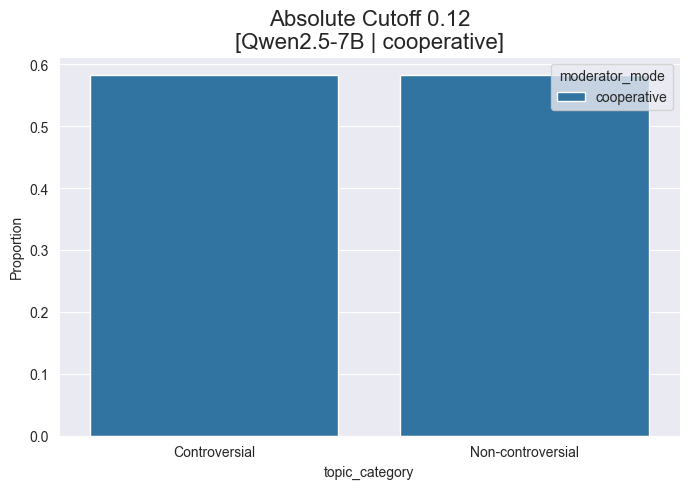

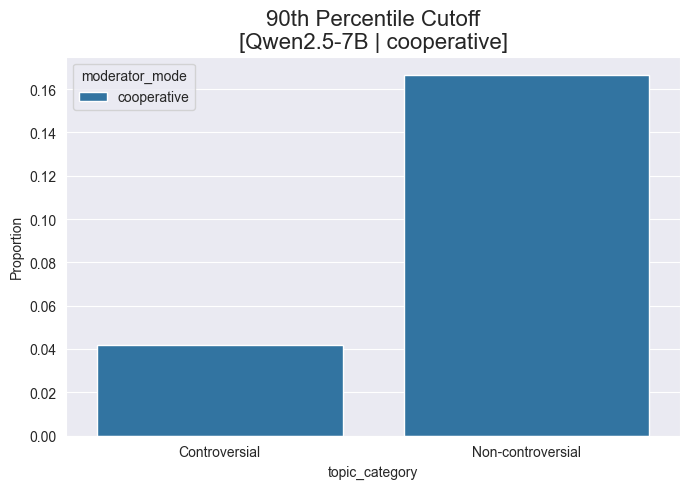

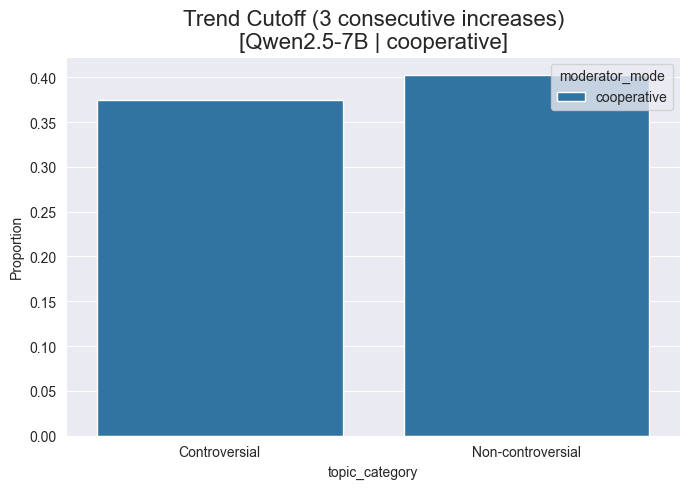


Analysis complete. Saved in: cutoff_plots


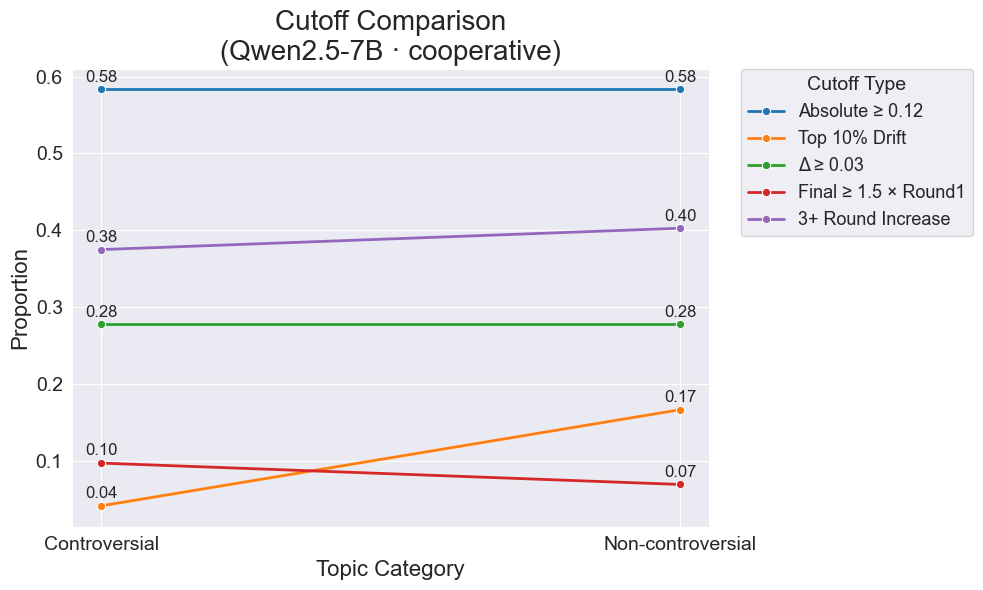

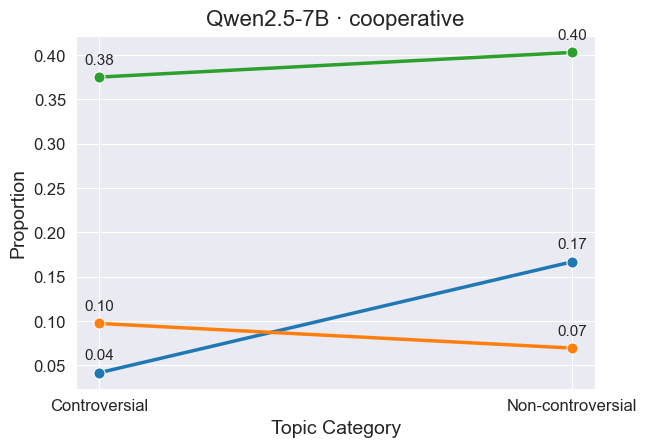

Saved main figure: Qwen2.5-7B_cooperative_CUTOFFS_MAIN.png
Saved legend-only figure: Qwen2.5-7B_cooperative_LEGEND_ONLY.png


In [26]:
df_long_coop = run_cutoff_analysis(
    csv_path="batch_debate_results_QWEN_cooperative.csv",
    model_name="Qwen2.5-7B",
    moderator_mode="cooperative"
)
plot_all_cutoffs(
    df_long=df_long_coop,
    model_name="Qwen2.5-7B",
    moderator_mode="cooperative"
)
plot_three_cutoffs(
    df_long=df_long_coop,
    model_name="Qwen2.5-7B",
    moderator_mode="cooperative"
)

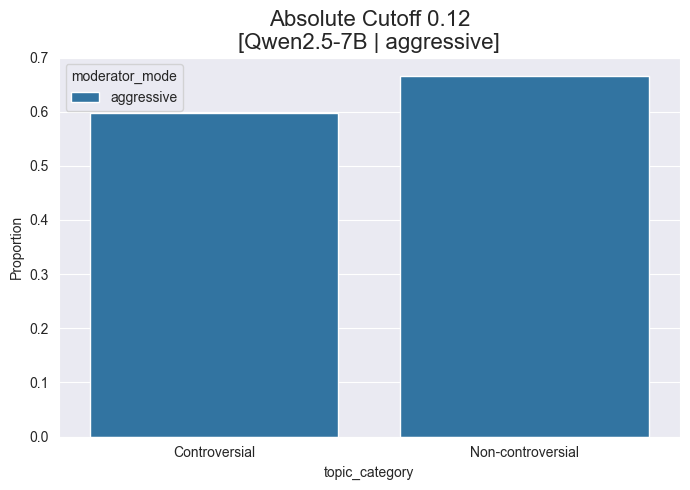

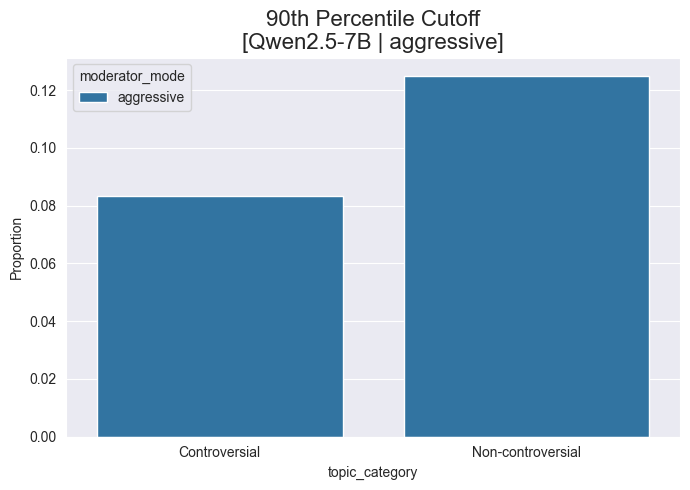

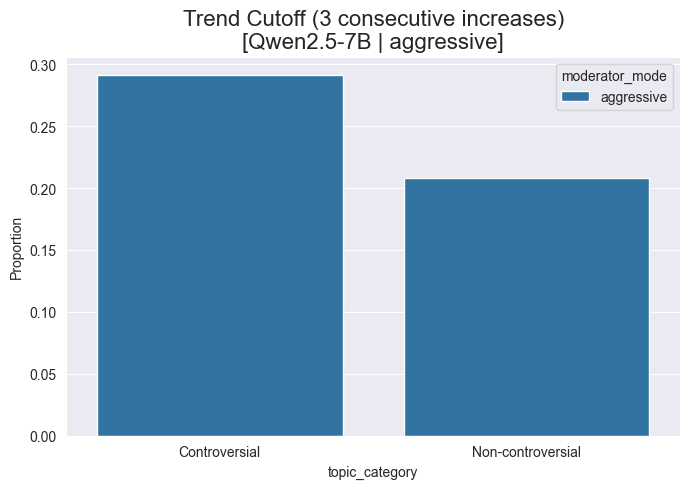


Analysis complete. Saved in: cutoff_plots


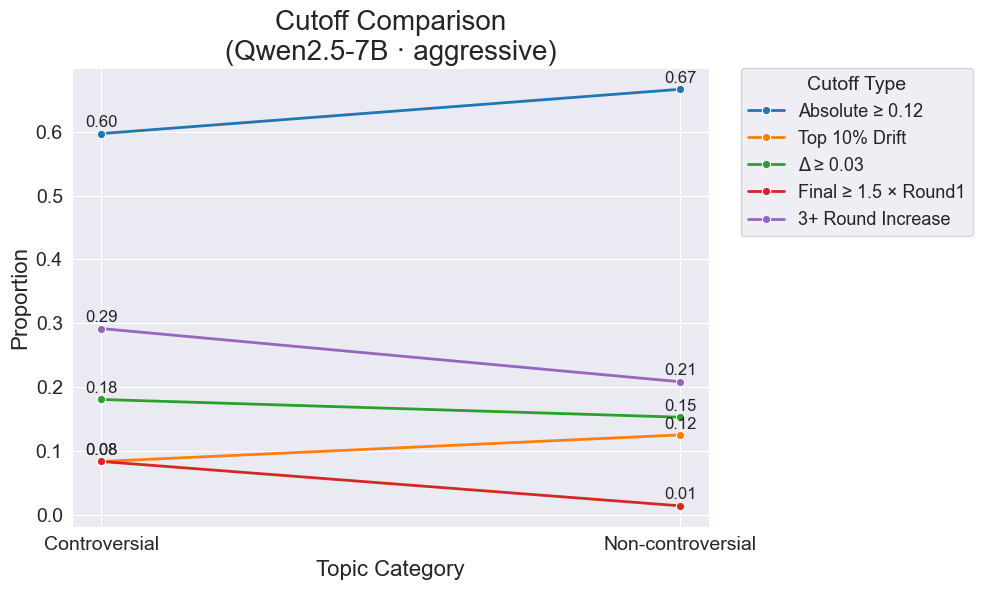

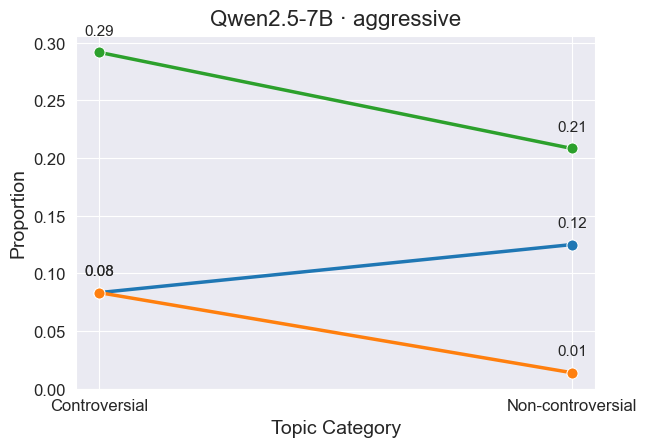

Saved main figure: Qwen2.5-7B_aggressive_CUTOFFS_MAIN.png
Saved legend-only figure: Qwen2.5-7B_aggressive_LEGEND_ONLY.png


In [27]:
df_long_aggr = run_cutoff_analysis(
    csv_path="batch_debate_results_QWEN_aggressive.csv",
    model_name="Qwen2.5-7B",
    moderator_mode="aggressive"
)

plot_all_cutoffs(
    df_long=df_long_aggr,
    model_name="Qwen2.5-7B",
    moderator_mode="aggressive"
)

plot_three_cutoffs(
    df_long=df_long_aggr,
    model_name="Qwen2.5-7B",
    moderator_mode="aggressive"
)

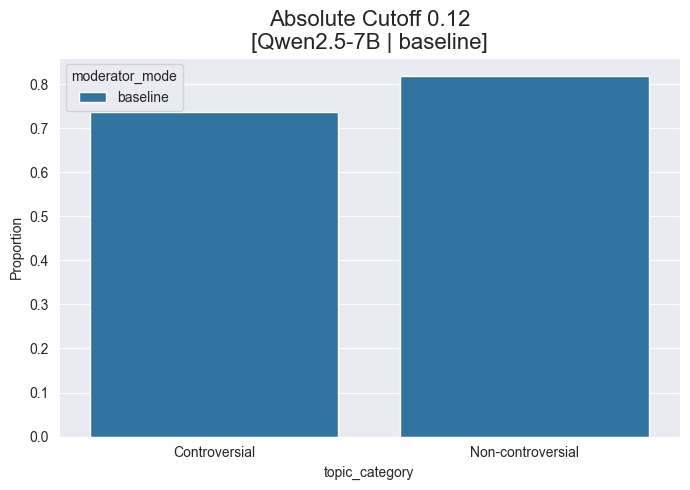

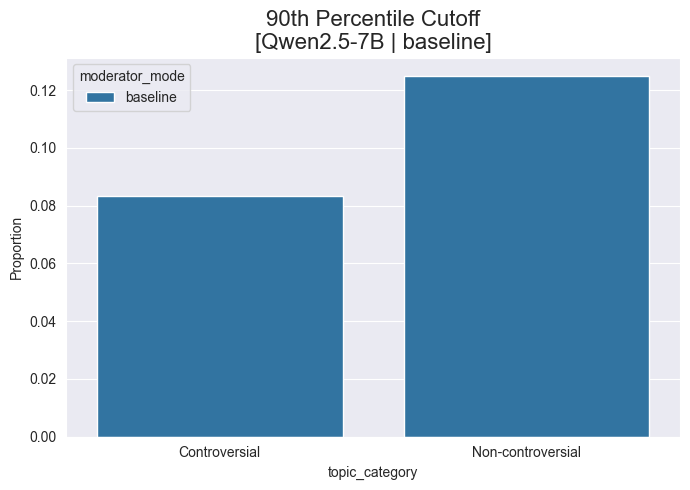

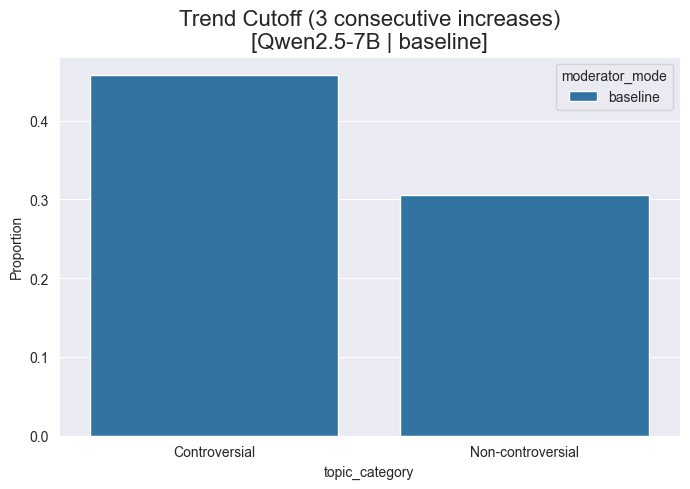


Analysis complete. Saved in: cutoff_plots


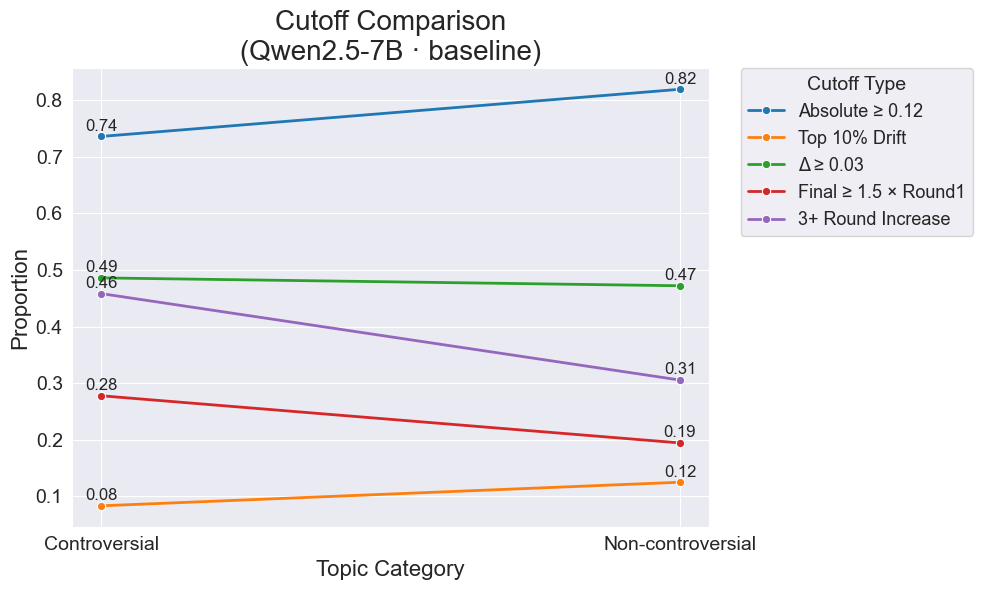

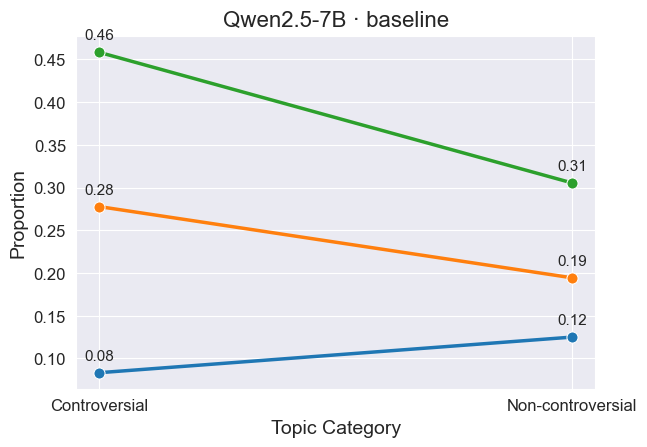

Saved main figure: Qwen2.5-7B_baseline_CUTOFFS_MAIN.png
Saved legend-only figure: Qwen2.5-7B_baseline_LEGEND_ONLY.png


In [28]:
df_long_base = run_cutoff_analysis(
    csv_path="batch_debate_results_QWEN_baseline.csv",
    model_name="Qwen2.5-7B",
    moderator_mode="baseline"
)

plot_all_cutoffs(
    df_long=df_long_base,
    model_name="Qwen2.5-7B",
    moderator_mode="baseline"
)

plot_three_cutoffs(
    df_long=df_long_base,
    model_name="Qwen2.5-7B",
    moderator_mode="baseline"
)

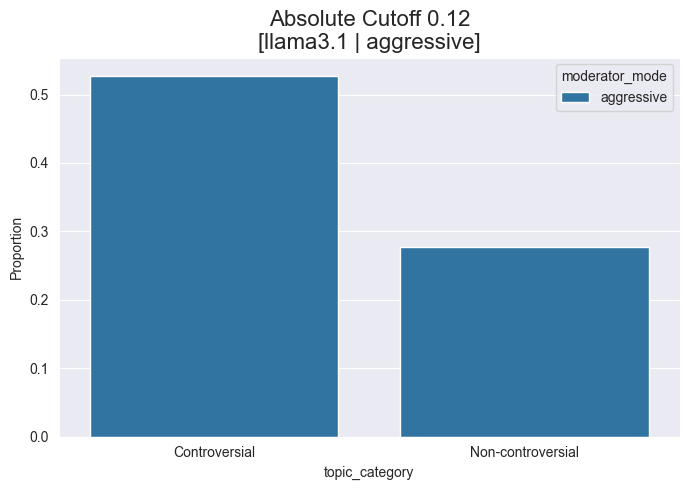

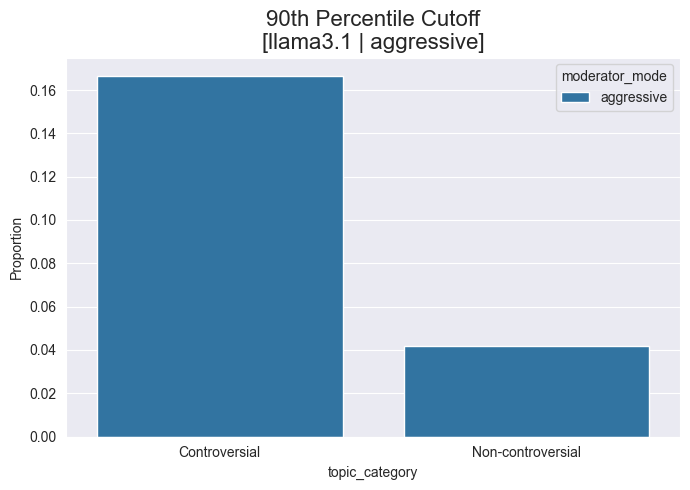

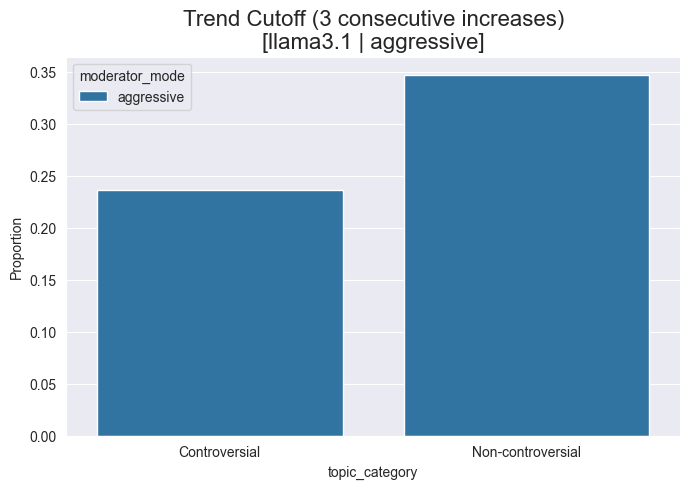


Analysis complete. Saved in: cutoff_plots


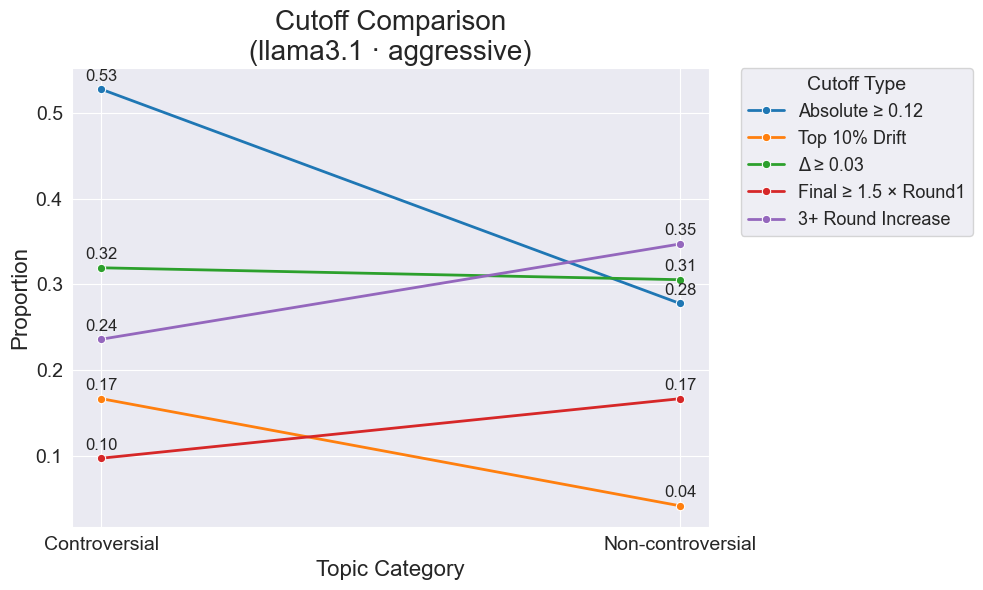

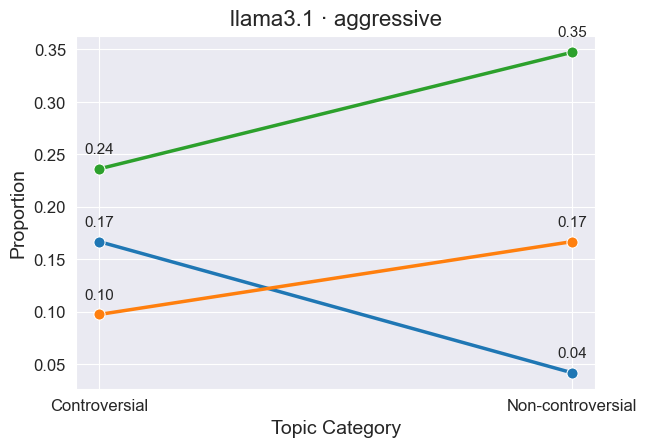

Saved main figure: llama3.1_aggressive_CUTOFFS_MAIN.png
Saved legend-only figure: llama3.1_aggressive_LEGEND_ONLY.png


In [30]:
df_long_aggr = run_cutoff_analysis(
    csv_path="batch_debate_results_LLAMA_aggressive.csv",
    model_name="llama3.1",
    moderator_mode="aggressive"
)

plot_all_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="aggressive"
)

plot_three_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="aggressive"
)

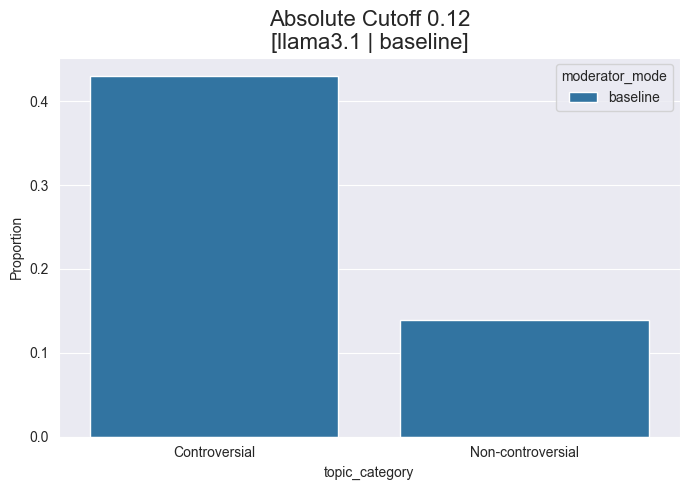

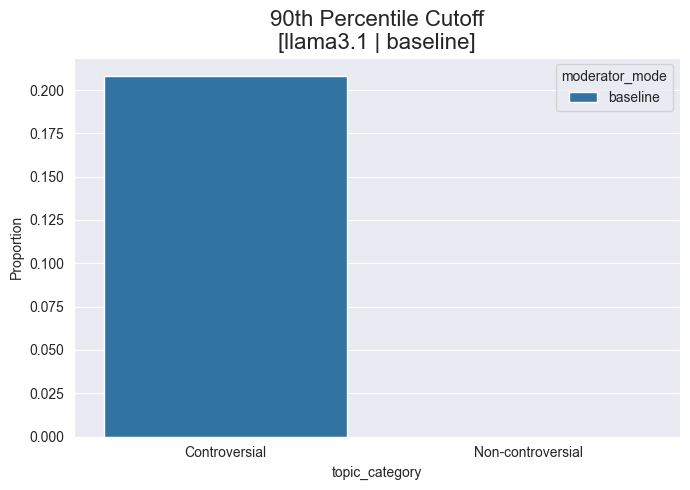

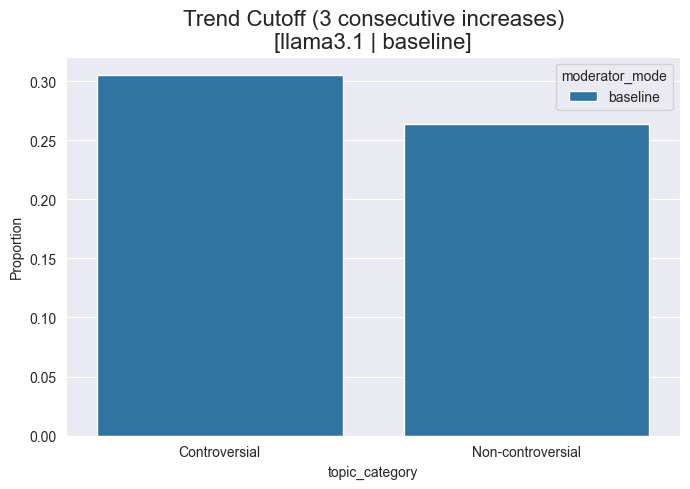


Analysis complete. Saved in: cutoff_plots


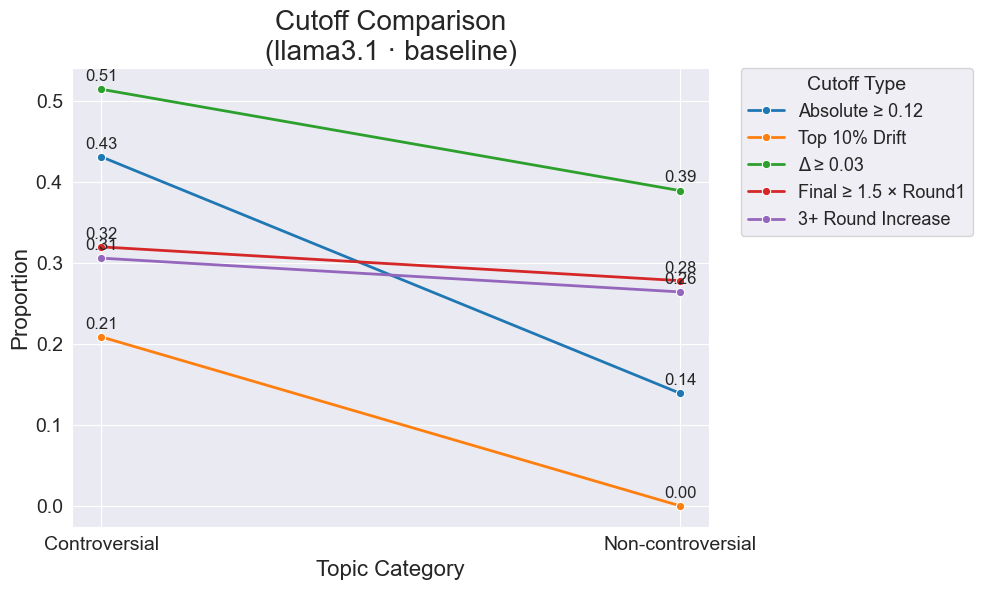

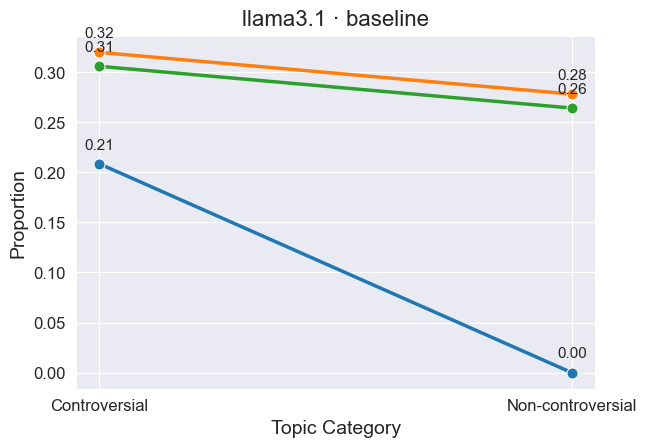

Saved main figure: llama3.1_baseline_CUTOFFS_MAIN.png
Saved legend-only figure: llama3.1_baseline_LEGEND_ONLY.png


In [31]:
df_long_aggr = run_cutoff_analysis(
    csv_path="batch_debate_results_LLAMA_baseline.csv",
    model_name="llama3.1",
    moderator_mode="baseline"
)

plot_all_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="baseline"
)

plot_three_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="baseline"
)

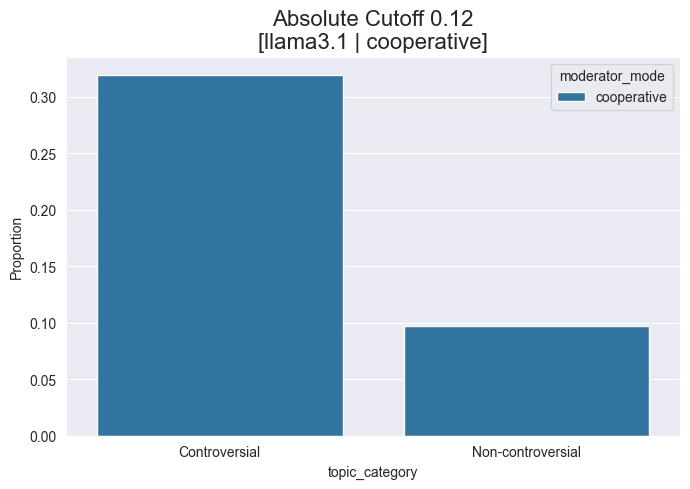

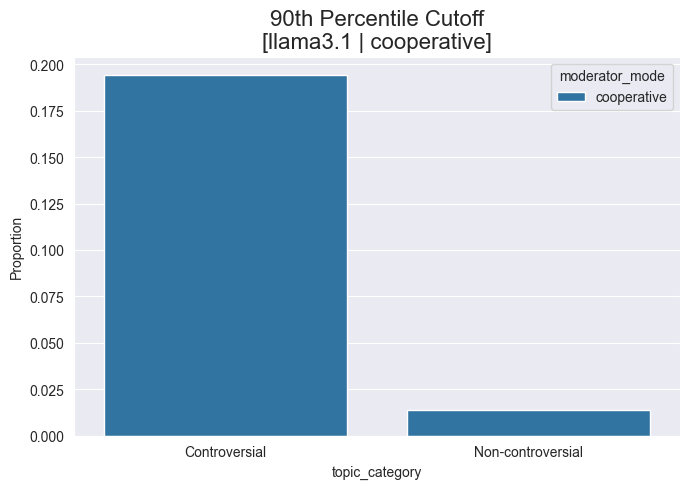

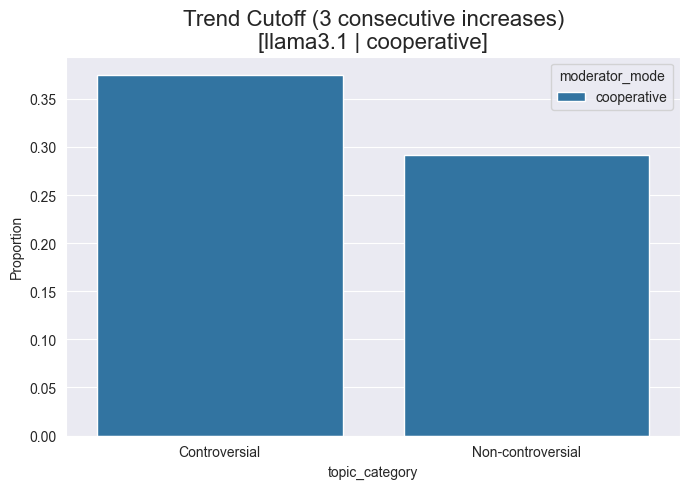


Analysis complete. Saved in: cutoff_plots


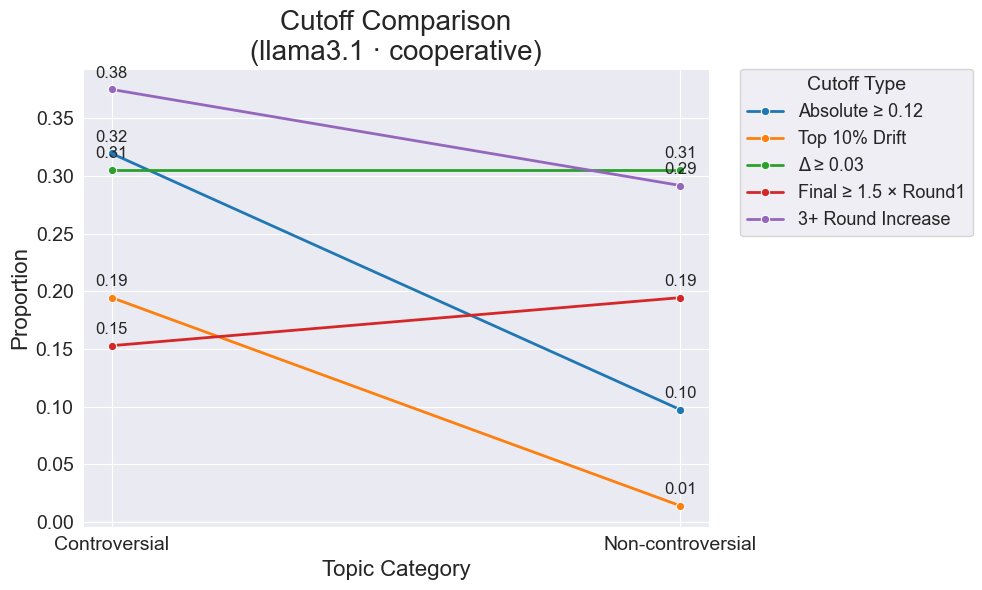

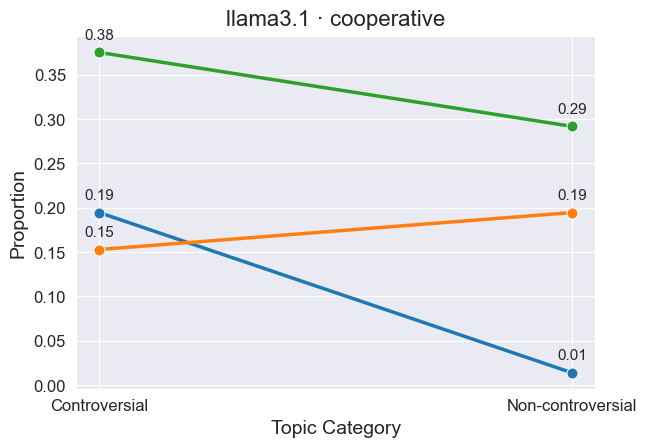

Saved main figure: llama3.1_cooperative_CUTOFFS_MAIN.png
Saved legend-only figure: llama3.1_cooperative_LEGEND_ONLY.png


In [32]:
df_long_aggr = run_cutoff_analysis(
    csv_path="batch_debate_results_LLAMA_cooperative.csv",
    model_name="llama3.1",
    moderator_mode="cooperative"
)

plot_all_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="cooperative"
)

plot_three_cutoffs(
    df_long=df_long_aggr,
    model_name="llama3.1",
    moderator_mode="cooperative"
)